# 02 -  Grundlagen: Das Perzeptron

# Das künstliche Neuron - das Perzeptron

<figure  style="text-align: center;">
    <img src="Bilder/Neuron_Hand-tuned2.svg" alt="Neuron" width = 300>
    <figcaption>Aufbau einer Nervenzelle. (CC BY-SA 4.0, https://commons.wikimedia.org/w/index.php?curid=151245917)</figcaption>
</figure>

Ein Neuron ist die Grundbaueinheit des Nervensystems. Es dient dazu, Informationen aufzunehmen, zu verarbeiten und weiterzuleiten – elektrisch und chemisch.

Ein typisches Neuron besteht aus drei Hauptteilen:

Dendriten

* kurze, verzweigte Fortsätze
* nehmen Signale von anderen Zellen auf

Zellkörper

* enthält den Zellkern
* verarbeitet die eingehenden Signale

Axon

* langer Fortsatz
* leitet elektrische Signale (Aktionspotenziale) weiter
* endet an Synapsen, wo das Signal an andere Neuronen oder Muskeln übertragen wird

  <figure  style="text-align: center;">
    <img src="Bilder/perceptron.svg" alt="Ein Perceptron" width = 500>
    <figcaption>Einfaches einlagiges Perceptron. </figcaption>
  </figure>

Das Perzeptron ist ein vereinfachtes künstliches neuronales Netz, das zuerst von Frank Rosenblatt 1958 (**F.Rosenblatt** The perceptron: a probabilistic model for information storage and organization in the brain, *doi: 10.1037/H0042519*) vorgestellt wurde. Es besteht in der Grundversion aus einem einzelnen künstlichen Neuron mit anpassbaren Gewichtungen und einem Schwellenwert. 

Das biologische Neuron ist das Vorbild für das künstliche Neuron. Das künstliche Neuron besteht aus folgenden Bestandteilen:
Einem Eingangsvektor, der die Eingangsdaten enthält, einem Gewichtungsvektor, der die Eingangsdaten wichtet und gewichtet weitergibt und einer Entscheidungsfunktion $\phi$, die das Ergebnis der gewichten Summe verarbeitet. Dabei wird eine Eins von der Entscheidungsfunktion weitergegeben (das Neuron aktiviert), wenn die gewichtete Summe einen Schwellenwert überschreitet und eine Null, wenn der Schwellenwert unterschritten wird. Das Ergebnis der Entscheidungsfunktion ist die Ausgabe $o$ des Perzetrons.

Die gewichtete Summe berechnet sich über

$$ z =  \begin{pmatrix} w_1 \\ w_2 \\ .. \\ w_n \end{pmatrix} \cdot \begin{pmatrix} x_1 \\ x_2 \\ .. \\ x_n \end{pmatrix}  = \sum_{i=1}^n w_i x_i = \boldsymbol{w}\cdot \boldsymbol{x}$$

Überschreitet die gewichtete Summe den Schwellenwert, wird das Neuron aktiviert.

$z > b \Leftrightarrow o - z > 0\longrightarrow o = \phi(z) = 1$ 

$z < b \Leftrightarrow o - z < 0\longrightarrow o = \phi(z) = 0$

Um eine kompaktere mathematische Darstellung zu erhalten, wird oft folgende Vorgehensweise gewählt: Der Schwellenwert $b$ wird in $-w_0$ umbenannt und in den Gewichtsvektor integriert. Damit ist

$$ z =   \begin{pmatrix} x_0 = 1 \\ x_1 \\ x_2 \\ .. \\ x_n \end{pmatrix}^T \begin{pmatrix} w_0 \\ w_1 \\ w_2 \\ .. \\ w_n \end{pmatrix}  = \boldsymbol{w}\cdot \boldsymbol{x}$$

$x_0$ ist dabei immer gleich 1. 

*Anmerkung:* Die Integration von $b$ in $\boldsymbol{w}$ ist aber nicht zwingend notwendig. In der Literatur werden beide Varianten verwendet. Bitte schauen Sie immer genau hin, welche Variante im Code gewählt wurde.

Beim einfachen Perzeptron ist die Entscheidungsfunktion dann eine Stufenfunktion mit

$$\phi = \delta(z) = \delta{\left(\sum_{i=1}^n x_i w_i\right)}$$

mit $z = \boldsymbol{x} \cdot \boldsymbol{w}$.

Im Folgenden werden Perceptronen zur Klassifizierung von Daten angewendet.

Als Aktivierungsfunktion wird eine einfache Stufenfunktion verwendet (siehe folgende Darstellung).

<>:28: SyntaxWarning: invalid escape sequence '\p'
<>:28: SyntaxWarning: invalid escape sequence '\p'
/var/folders/g6/0fy4qql97sl5cl745c6s82jw0000gn/T/ipykernel_28107/1431539146.py:28: SyntaxWarning: invalid escape sequence '\p'
  plt.title("Aktivierungsfunktion $\phi$");


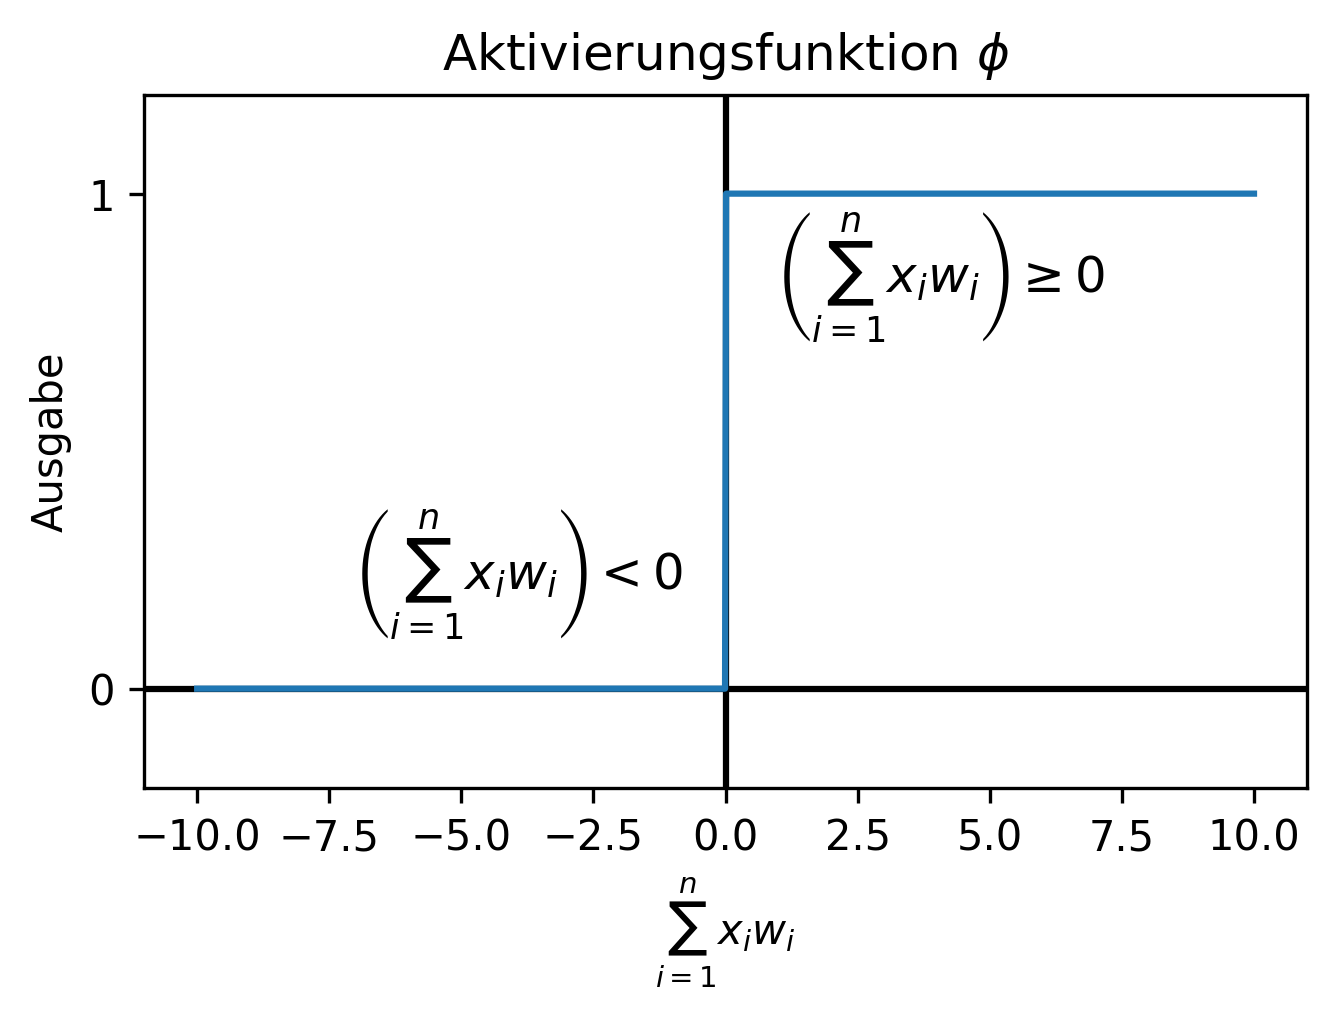

In [4]:
#| code-fold: true
#| code-summary: "Code anzeigen"

import numpy as np
import matplotlib.pyplot as plt

# Wertebereich definieren
z = np.linspace(-10, 10, 1000)

# Stufenfunktion definieren
def step_function(z):
    return np.where(z < 0, 0, 1)

# Funktionswerte berechnen
y = step_function(z)

# Plot erstellen
plt.figure(figsize = (5,3), dpi=300)
plt.axhline(0, color = 'black')
plt.axvline(0, color = 'black')
plt.plot(z, y)
plt.text(-7, 0.2, r'$\left(\sum_{i=1}^n x_i w_i\right) < 0$', fontsize=12)
plt.text(1, 0.8, r'$\left(\sum_{i=1}^n x_i w_i\right) \geq 0$', fontsize=12)
plt.xlabel(r'$\sum_{i=1}^n x_i w_i$')
plt.ylabel('Ausgabe')
plt.yticks([0, 1])
plt.ylim(-0.2, 1.2)
plt.title("Aktivierungsfunktion $\phi$");


## Beispiel 1: Roboter

In diesem Beispiel wird demonstriert, wie die Berechnung der gewichteten Summe im Perzeptron zu einer Entscheidung führt.

In Anlehnung an: Steinwendner, J.; Schwaiger, R.: Neuronale Netze programmieren mit Python


Ein Roboter soll mit einem Perzeptron gesteuert werden, so dass er einer Wand ausweichen kann.
Der Roboter hat links und rechts jeweils einen Abstandssensor montiert, der messen kann, ob ein Mindestabstand zu einem Hindernis unterschritten wird. 

Dazu sollen die Gewichte so bestimmt werden, dass der Roboter erkennt, dass ein Problem vorliegt, wenn beide Sensoren einen zu geringen Abstand erkennen. 

 <figure style="text-align: center;">
    <img src="Bilder/roboter.png" alt="Roboter" width = 500>
    <figcaption>Roboter mit zwei Sensoren</figcaption>
  </figure>

### Wertetabelle

Stellen Sie die dazugehöhrende Wertetabelle auf!

::: {.callout-note collapse="true"}

### Lösung aufklappen

Fall Nr.| Sensor links | Sensor rechts | Ergebnis
--------|--------|--------|--------
1|0|0|0
2|0|1|0
3|1|0|0
4|1|1|1

:::

### Forward-Berechnung

Beschreiben Sie die Eingangsdaten in Matrixdarstellung $\mathbf{X}$ und die gewünschten Ausgabedaten $\boldsymbol{y}$ nach Wertetabelle. 
Bestimmen Sie passende Gewichte , so dass eine Gerade die Daten nach gewünschtem Ergebnis trennt. 

::: {.callout-note collapse="true"}

### Lösung aufklappen

$$\mathbf{X} = \begin{pmatrix} 1 & 0 & 0 \\ 1 & 0 & 1 \\ 1 & 1 & 0 \\ 1 & 1 & 1 \end{pmatrix}$$

$$\boldsymbol{y} = \begin{pmatrix} 0 \\ 0 \\ 0 \\ 1 \end{pmatrix}$$

$$\boldsymbol{w} = \begin{pmatrix} -2 \\ 1 \\ 1 \end{pmatrix}$$

$$ \mathbf{X} \cdot \boldsymbol{w}  = \begin{pmatrix} 1 & 0 & 0 \\ 1 & 0 & 1 \\ 1 & 1 & 0 \\ 1 & 1 & 1 \end{pmatrix} \cdot \begin{pmatrix} -2 \\ 1 \\ 1 \end{pmatrix}  = \begin{pmatrix} -2 + 0 + 0 \\ -2+0+1 \\ -2+1+0 \\ -2+1+1 \end{pmatrix} = \begin{pmatrix} -2 \\ -1 \\ -1 \\ 0 \end{pmatrix}$$

$$\phi \left(\mathbf{X} \cdot \boldsymbol{w} \right) = \phi \begin{pmatrix} -2 \\ -1 \\ -1 \\ 0 \end{pmatrix} = \begin{pmatrix} 0 \\ 0 \\ 0 \\ 1 \end{pmatrix}$$

:::

### Berechnung mit numpy

Schreiben Sie ein Programm in Python, welches die gewichtete Summe berechnet und das Ergebnis ausgibt.

In [2]:
#| code-fold: true
#| code-summary: "Code anzeigen"

import numpy as np
import matplotlib.pyplot as plt

# 3-dimensionaler Input = Bias-Neuron, Sensor links, Sensor rechts
# 4 Inputvektoren, da vier Fälle
X = np.array([[1,0,0],[1,0,1],[1,1,0],[1,1,1]])
# Die 4 gewünschten Ergebniswerte
y = np.array([0,0,0,1])

# Heaviside-Funktion
def heaviside( summe ):
    """Stufenfunktion"""
    if summe >= 0:
        return 1
    else:
        return 0
    
# Perceptron-Berechnung 
def perceptron_eval(X,y):
    """ Perceptron-Berechnung"""
    # Der Gesamtfehler
    gesamtfehler = 0;
    # Die Gewichte so wählen, dass das Roboter-Problem gelöst werden kann
    w = np.array([-2,1,1])
    # Index i und Element x Ermittlung vom Array X
    for i, x in enumerate(X):
        # x = Zeile für Zeile verwenden
        # Inneres Produkt zwischen x und w
        summe = np.dot(w,x)
        #print('Summe:', summe)
    ergebnis = heaviside(summe)
    # Fehler
    fehler = np.abs(ergebnis - y[i])
    # Gesamtfehler
    gesamtfehler += fehler
    # Ausgabe
    print("Sensor L = {}".format(x[1]))
    print("Sensor R = {}".format(x[2]))
    print("gewünschtes Ergebnis = {}".format(y[i]))
    print("errechnetes Ergebnis = {}".format(ergebnis))
    print("Fehler = {}".format(fehler))
    # Gesamtfehler pro Epoche über ganzen Trainingsdatensatz
    return gesamtfehler

gesamtfehler = perceptron_eval(X,y)
print("Gesamtfehler = %1d" % (gesamtfehler))

Sensor L = 1
Sensor R = 1
gewünschtes Ergebnis = 1
errechnetes Ergebnis = 1
Fehler = 0
Gesamtfehler = 0


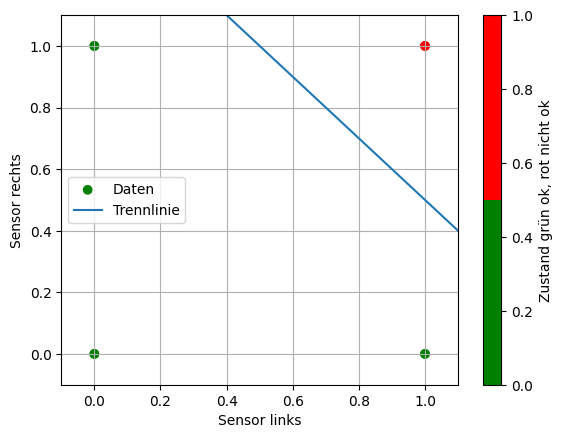

In [3]:
#| code-fold: true
#| code-summary: "Code anzeigen"

import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
import numpy as np

sensorlinks = [0,1,0,1]
sensorrechts = [0,0,1,1]

karte = []
for i in range(len(sensorlinks)):
    karte.append(sensorlinks[i] + sensorrechts[i])

colors = ['green','green','red']
cmap = ListedColormap(colors)

plt.scatter(sensorlinks, sensorrechts, c = karte, cmap = cmap, label = 'Daten')
plt.xlabel('Sensor links')
plt.ylabel('Sensor rechts')
plt.grid()

# Farblegende hinzufügen
karte = []
for i in range(len(sensorlinks)):
    karte.append(1 if sensorlinks[i] and sensorrechts[i] else 0)
cmap = ListedColormap(['green', 'red'])
sc = plt.scatter(sensorlinks, sensorrechts, c=karte, cmap=cmap)
plt.colorbar(sc, label='Zustand grün ok, rot nicht ok')

xwerte = np.linspace(-1.1,1.1,100)
ywerte = 1.5 - xwerte*1
plt.plot(xwerte, ywerte, label='Trennlinie')
plt.xlim([-0.1,1.1])
plt.ylim([-0.1,1.1])
plt.legend()
plt.savefig('Bilder/roboter.png', dpi = 300)

## Beispiel 2: Basilikum

Der Roboter hatte genau zwei Sensoren. In diesem Beispiel wird noch einmal die Forward-Berechnung betrachtet, allerdings mit einer zusätzlichen Messstelle.

Die Feuchtigkeit der Erde einer Basilikumpflanze wird durch 3 Messstellen überprüft. Zeigen 2 oder mehr Messungen (2 von 3 Auswahl) einen kritischen Wert an, muss bewässert werden. 

In [4]:
#| code-fold: true
#| code-summary: "Lösung anzeigen"

# Mathematik
import numpy as np
# Plot
import matplotlib.pyplot as plt
# 4-dimensionaler Input = Bias-Neuron, messung1, messung2, messung3
# 8 Inputvektoren
X = np.array([[1,0,0,0],
              [1,0,0,1],
              [1,0,1,0],
              [1,0,1,1],
              [1,1,0,0],
              [1,1,0,1],
              [1,1,1,0],
              [1,1,1,1]])
# Die 4 gewünschten Ergebniswerte
y = np.array([0,0,0,1,0,1,1,1])

# Heaviside-Funktion
def heaviside( summe ):
    """Stufenfunktion"""
    if summe >= 0:
        return 1
    else:
        return 0
    
# Perceptron-Berechnung
def perceptron_eval(X,y):
    """ Perceptron-Berechnung """
    # Der Gesamtfehler
    gesamtfehler = 0;
    # Gewichte
    w = np.array([-2,1,1,1])
   
    for i, x in enumerate(X):
        summe = np.dot(w,x)
    ergebnis = heaviside(summe)
    # Fehler
    fehler = np.abs(ergebnis - y[i])
    # Gesamtfehler
    gesamtfehler += fehler
    # Ausgabe
    print("Messung 1 = {}, Messung 2 = {}, Messung 3 = {}, gewünschtes Ergebnis ={}, errechnetes Ergebnis = {}, Fehler = {}".format(x[1], x[2], x[3], y[i], ergebnis, fehler))
    # Gesamtfehler über ganzen Trainingsdatensatz
    return gesamtfehler

gesamtfehler = perceptron_eval(X,y)
print("Gesamtfehler = %1d" % (gesamtfehler))

Messung 1 = 1, Messung 2 = 1, Messung 3 = 1, gewünschtes Ergebnis =1, errechnetes Ergebnis = 1, Fehler = 0
Gesamtfehler = 0


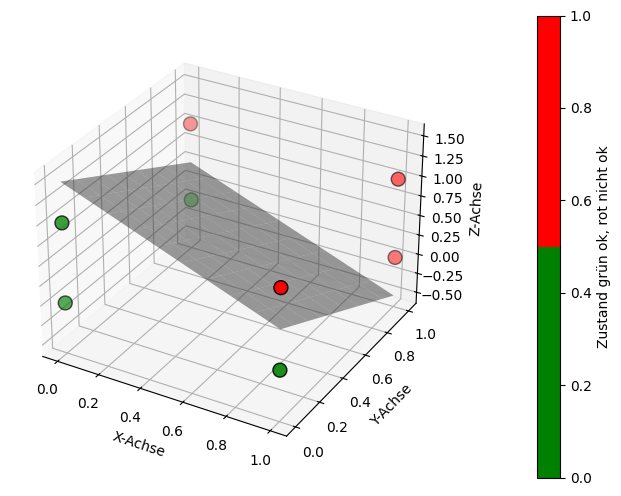

In [5]:
#| code-fold: true
#| code-summary: "Lösung anzeigen"

import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from matplotlib.colors import ListedColormap

# Werte für die Achsen
x = np.array([0,0,0,0,1,1,1,1])
y = np.array([0,0,1,1,0,0,1,1])
z = np.array([0,1,0,1,0,1,0,1])

# Farben für die Punkte
c = np.array([0,0,0,1,0,1,1,1])

# Erstelle eine 3D-Figur
fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection='3d')

colors = ['green', 'red']
cmap = ListedColormap(colors)

# Scatter-Plot mit Farbzuweisung
sc = ax.scatter(x, y, z, c=c, cmap=cmap, s=100, edgecolors="k")

# Achsentitel setzen
ax.set_xlabel("X-Achse")
ax.set_ylabel("Y-Achse")
ax.set_zlabel("Z-Achse")

# Farblegende hinzufügen
plt.colorbar(sc, ax=ax, pad=0.15, label="Zustand grün ok, rot nicht ok")

# Trennebene einfügen
xx, yy = np.meshgrid(np.linspace(0, 1, 10), np.linspace(0, 1, 10))
zz = 2 - 0.5 * np.ones_like(xx)- xx - yy  # Eine horizontale Trennebene bei z=0.5

ax.plot_surface(xx, yy, zz, color='gray', alpha=0.5)  # Halbtransparente Trennebene


Die Trennlinien wurden in den beiden Beispielen nicht gelernt, sondern manuell festgelegt, um das Prinzip zu verdeutlichen.
Dabei stellen die dargestellten Trennlinien nur ein Beispiel dar, es würde natürlich auch jede andere Trennlinie funktionieren, die beide Gruppen teilt. 

Im Folgenden wird demonstriert, wie eine mögliche Trennlinie durch das Perzeptron aus den Daten gelernt werden kann.

# Wie lernt das Perzeptron?



<figure style="text-align: center;">
    <img src="Bilder/perceptron_lernen.svg" alt="Neuron" width = 500>
    <figcaption>Lernen beim klassischen Perzeptrons</figcaption>
</figure>


Bislang hat das Perzeptron nichts gelernt, sondern nur mit gegebenen Gewichten die Vorhersage berechnet. Im folgenden Beispiel wird erklärt, wie das Perzeptron lernt.
Ziel des Lernes ist es, aus den Daten eine mögliche Trennlinie zu bestimmen, welche die Daten richtig klassifiziert. Als Aktivierungsfunktion wird wieder eine einfache Stufenfunktion verwendet.

$$\phi = \delta(\boldsymbol{x},\boldsymbol{w}) = \delta{\left(\sum_{i=1}^n x_i w_i\right)}$$

## Beispiel 3: Kraftwerksschicht
Die Mannschaft der Leitstelle eines kleinen Kraftwerks besteht aus 4 Mitarbeitern (Herr Meier, Frau Müller, Herr Koslowski und Frau Schmidt). Da auf der Leitstelle das 4-Augen Prinzip gilt, müssen immer mindestens 2 Personen anwesend sein, damit die Anlage sicher betrieben werden kann. 

### Wertetabelle

Fertigen Sie eine Tabelle an, aus der ersichtlich ist, ob eine Kombination von Anwesenheiten auf der Leitstelle OK (1) oder nicht OK (0) ist.

::: {.callout-note collapse="true"}
## Lösung anzeigen

Herr Meier | Frau Müller | Herr Koslowski | Frau Schmidt | Anwesenheitskombination OK(1)/nicht OK(0)
-----------|-------------|----------------|--------------|------------------------------------------
0 | 0 | 0 | 0 | 0 
0 | 0 | 0 | 1 | 0 
0 | 0 | 1 | 0 | 0 
0 | 0 | 1 | 1 | 1 
0 | 1 | 0 | 0 | 0 
0 | 1 | 0 | 1 | 1
0 | 1 | 1 | 0 | 1
0 | 1 | 1 | 1 | 1
1 | 0 | 0 | 0 | 0
1 | 0 | 0 | 1 | 1
1 | 0 | 1 | 0 | 1
1 | 0 | 1 | 1 | 1
1 | 1 | 0 | 0 | 1
1 | 1 | 0 | 1 | 1
1 | 1 | 1 | 0 | 1
1 | 1 | 1 | 1 | 1

:::

Die Tabelle liefert die Daten, mit denen das Perzeptron trainiert werden kann. Zu jedem Eingangsvektor $\boldsymbol{x}$ liefert die Tabelle ein gewünschtes Ergebnis $y$. 

$\begin{pmatrix} x_0 \\x_1 \\ x_2 \\ .. \\ x_n \end{pmatrix} \cdot \begin{pmatrix} w_0 \\ w_1 \\ w_2 \\ .. \\ w_n \end{pmatrix} = \sum_{i=1}^n x_i w_i$

Dies bedeutet, um zu Lernen, müssen die Gewichte $w_i$ bestimmt werden, so dass, wenn das Ergebnis nicht ok ist, das Ergebnis der gewichteten Summe kleiner als der Schwellenwert der Stufenfunktion, beziehungsweise kleiner Null, wenn der Schwellenwert als $-w_0$ integriert wird. 

Das Lernen besteht aus dem Ändern der Gewichte. Um zu wissen, wir die Gewichte geändert werden, muss der Abstand des Perzeptron-Outputs mit dem gewünschten Output berechnet werden. Der gewünschte Output ist über die Wertetabelle bekannt.

Dies bedeutet für das Perzeptron:

* ist $o_T < y_T$ werden die Gewichte erhöht um $\Delta w_{i,T} = (y_T - o_T)$
* ist $o_T > y_T$ werden die Gewichte erniedrigt um $\Delta w_{i,T} = (o_T - y_T)$

Damit nur diejenigen Gewichte verändert werden, die auch zum Fehler beitragen, muss noch mit dem entsprechenden Eingangswert multipliziert werden.

* ist $o_T < y_T$ werden die Gewichte erhöht um $\Delta w_{i,T} = (y_T - o_T)\cdot x_{i,T}$
* ist $o_T > y_T$ werden die Gewichte erniedrigt um $\Delta w_{i,T} = (o_T - y_T)\cdot x_{i,T}$

Zusammenfassend gilt die Perzeptron-Lernregel (nach Rosenblatt):

$$z = \boldsymbol{w}\cdot\boldsymbol{x}$$
$$o = sign(z)$$
$$\boldsymbol{w} \mathrel{+}=  \Delta \boldsymbol{w}  = (y-o)\cdot\boldsymbol{x}$$

Da das Ergebnis in diesem einfachsten Fall immer nur 0 (ok) oder 1 (nicht ok) sein kann, kann die Änderung der Gewichte auch immer nur um $\pm 1$ erfolgen.

### Perzeptron programmieren:

In [6]:
#| code-fold: true
#| code-summary: "Code anzeigen"

import numpy as np
import matplotlib.pyplot as plt

# Choice wählt eine zufällige Zeile aus einem Array
from random import choice  

heaviside = lambda x:0 if x<0 else 1

def fit(iterations, training_data_set, w):
    errors = []
    weights = []
    
    for i in range(iterations):
        ## zufällige Trainingsdaten (entspricht einer Zeile) 
        # aus dem Traningsdatensatz herauspicken
        training_data = choice(training_data_set)  
        x = training_data[0]
        y = training_data[1]
                
        #ergebnis berechnen
        o = heaviside(np.dot(w,x))
        # differenz zu gewünschtem Ergebnis berechnen
        error = y - o
        #print(error)
        
        errors.append(error) ## Verlauf der Fehler protokollieren
        weights.append(w.copy())  ## Verlauf der Gewichte protokollieren
        #print(errors, weights)
        
        # Anpassung der Gewichte, immer in Schritten +- 1
        w += error*x
    return errors,weights

### Darstellung der Trainingsdaten
Die Trainingsdaten werden nach Schichtplan erstellt und grafisch dargestellt.

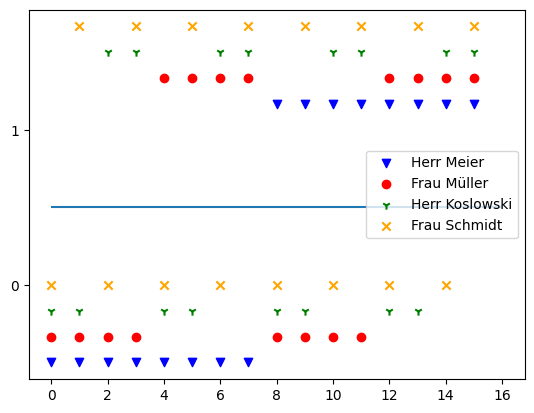

In [7]:
#| code-fold: true
#| code-summary: "Code anzeigen"

## definiere Trainingsdaten: Liste mit Tupeln aus je Inputdaten
## Array mit Bias-neuron, Herr Meier, Frau Müller, Herr Koslowski, Frau Schmidt
## und gewünschtem Ergebnis

training_data_set = [
    (np.array([1,0,0,0,0]),0),(np.array([1,0,0,0,1]),0),(np.array([1,0,0,1,0]),0),(np.array([1,0,0,1,1]),1),
    (np.array([1,0,1,0,0]),0),(np.array([1,0,1,0,1]),1),(np.array([1,0,1,1,0]),1),(np.array([1,0,1,1,1]),1),
    (np.array([1,1,0,0,0]),0),(np.array([1,1,0,0,1]),1),(np.array([1,1,0,1,0]),1),(np.array([1,1,0,1,1]),1),
    (np.array([1,1,1,0,0]),1),(np.array([1,1,1,0,1]),1),(np.array([1,1,1,1,0]),1),(np.array([1,1,1,1,1]),1)
]

## Offset hinzufügen, damit die Daten im Plot besser zu erkennen sind
liste_x1_werte = [training_data_set[i][0][1] for i in range(len(training_data_set))]
liste_x2_werte = [training_data_set[i][0][2]+0.1 for i in range(len(training_data_set))]
liste_x3_werte = [training_data_set[i][0][3]+0.2 for i in range(len(training_data_set))]
liste_x4_werte = [training_data_set[i][0][4]+0.3 for i in range(len(training_data_set))]
liste_y_werte = [training_data_set[i][1] for i in range(len(training_data_set))]

## Scatterplot der Trainingsdaten
plt.scatter(list(range(len(liste_x1_werte))),liste_x1_werte, label = 'Herr Meier', marker = 'v', c = 'b')
plt.scatter(list(range(len(liste_x2_werte))),liste_x2_werte, label = 'Frau Müller', marker = 'o', c = 'r')
plt.scatter(list(range(len(liste_x3_werte))),liste_x3_werte, label = 'Herr Koslowski', marker = '1', c = 'g')
plt.scatter(list(range(len(liste_x4_werte))),liste_x4_werte, label = 'Frau Schmidt', marker = 'x', c = 'orange')


plt.yticks([0.3,0.9],[0,1])
plt.hlines(0.6,0,16)
plt.legend()

plt.show()

### Perzeptron trainieren 

Nun kann das Perzeptron trainiert werden. Der Verlauf des Trainings wird grafisch dargestellt.

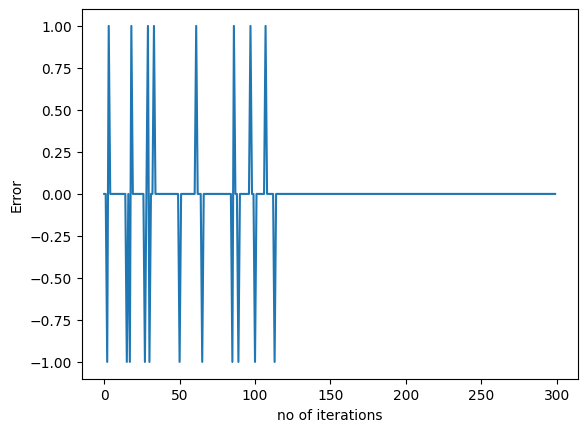

Die Gewichte nach Training der Daten sind:  [-2.9  2.1  2.1  2.1  1.1]
Der Gesamtfehler nach Training ist:  0


In [8]:
#| code-fold: true
#| code-summary: "Code anzeigen"

##Startgewichte wählen, könnte man auch zufällig beispielsweise mit np.random.seed(5) machen
w = np.ones(5)/10
#np.random.seed(30)
#w = np.random.rand(5) 
iterations = 300

errors, weights = fit(iterations, training_data_set, w)

plt.plot(errors)
plt.xlabel('no of iterations')
plt.ylabel('Error')
plt.show()

print("Die Gewichte nach Training der Daten sind: ", weights[len(weights)-1])
print("Der Gesamtfehler nach Training ist: ", errors[len(errors)-1])

### Aufgabe 1: Variationen im Perzeptron

1. Überprüfen Sie das gefundene Ergebnis!
1. Verändern Sie den Code, um ein Gefühl für das Perzeptron-Lernen zu bekommen. Variieren Sie beispielsweise die Startwerte, die Anzahl der Iterationen usw.

Die Wertetabelle für die Kraftwerksschicht ist noch recht überschaubar. 
Oft sind die Datensätze, aus denen gelernt werden soll, deutlich größer und komplexer. In den zwei folgenden Beispielen werden größere Datensätze verwendet, um das Trainineren eines Perzeptrons zu üben. 

In [9]:
#| include: false

#Verlauf der Gewichte während des Trainings


#| code-fold: true
#| code-summary: "Code anzeigen"

#for i in range(len(weights)):
#    print(weights[i])

## Der Iris-Datensatz

In dieser Aufgabe wird der Iris-Datensatz verwendet. Der Iris-Datensatz ([https://de.wikipedia.org/wiki/Schwertlilien-Datensatz](https://de.wikipedia.org/wiki/Schwertlilien-Datensatz)) beinhaltet Messwerte der Länge und Breite der Kelchblätter von drei verschiedenen Iris-Arten und gehört zu den Klassikern von Übungsdatensätzen. 

Der Datensatz ist [hier](Daten/Perzeptron/iris.csv) zu finden. Der Datensatz enthält 150 Messungen von Iris-Pflanzen von fünf Attributen: 

* Länge des Kelchblatts (sepal lengh)
* Breite des Kelchblatts (sepal width)
* Länge des Kronblatts (petal length)
* Breite des Kronblatts (petal width)
* Spezies

Zunächst bietet es sich immer an, einen Datensatz zu visualisieren, beispielsweise mit Scatter-Plots.

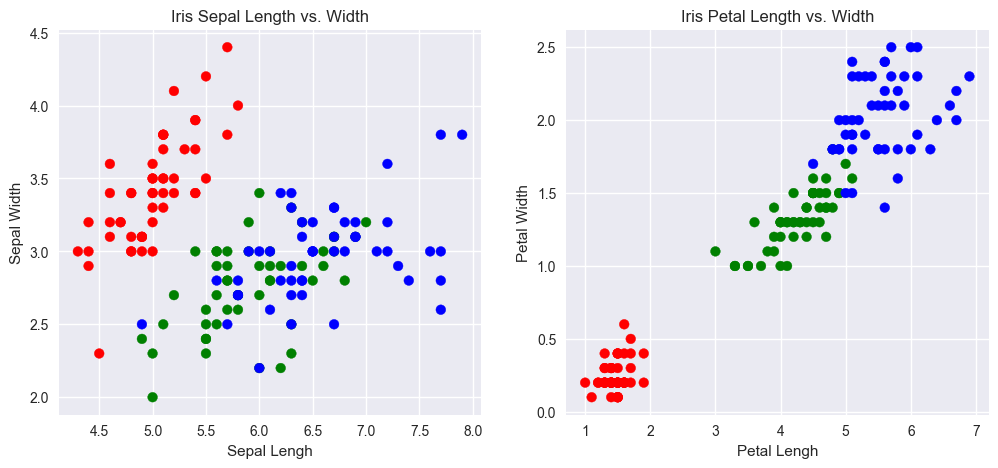

In [10]:
#| code-fold: true
#| code-summary: "Code anzeigen"

import numpy as np
import matplotlib.pyplot as plt
from random import choice  ##The choice() method returns a randomly selected element from the specified sequence.

sepal_lengh = []
sepal_width = []
petal_length = []
petal_width = []
colors = []
colors_values = []
iris_colors = {'Iris-setosa' : 'red', 'Iris-versicolor' : 'green' , 'Iris-virginica' : 'blue'}

with open('Daten/Perzeptron/iris.csv', 'r') as fobj:
    for line in fobj:
        words = line.rstrip().split(',')
        if len(words) != 5:
            continue
        #print(words)
        sepal_lengh.append(float(words[0]))
        sepal_width.append(float(words[1]))
        petal_length.append(float(words[2]))
        petal_width.append(float(words[3]))
        colors.append(iris_colors[words[4]])

plt.style.use('seaborn-v0_8')
plt.figure(figsize=(12,5))
ax1 = plt.subplot(1,2,1)
ax1.set_xlabel('Sepal Lengh')
ax1.set_ylabel('Sepal Width')
ax1.set_title('Iris Sepal Length vs. Width')
ax1.scatter(np.array(sepal_lengh), np.array(sepal_width), color = colors)
ax2 = plt.subplot(1,2,2)
ax2.set_xlabel('Petal Lengh')
ax2.set_ylabel('Petal Width')
ax2.set_title('Iris Petal Length vs. Width')
ax2.scatter(np.array(petal_length), np.array(petal_width), color = colors)
plt.show()

Wie leicht zu erkennen ist, lassen sich die Iris-Arten Iris-versicolor und Iris-virginica nicht gut mit den ermittelten Kriterien trennen. 
Die Iris-Art Iris-setosa unterscheidet sich jedoch deutlich. 

Im nächsten Schritt soll daher ein Perzeptron trainiert werden, welches Iris-setosa von den anderen beiden Iris-Arten unterscheiden kann. 
Daher werden den Iris-Arten nun Werte zur Klassenzugehörigkeit zugeortnet:

Iris-setosa --> 0
Iris-versicolor --> 1
Iris-virginica --> 1



In [11]:
#| code-fold: true
#| code-summary: "Code anzeigen"

import numpy as np
import matplotlib.pyplot as plt
from random import choice  ##The choice() method returns a randomly selected element from the specified sequence.

sepal_lengh = []
sepal_width = []
petal_length = []
petal_width = []
colors = []
colors_values = []
iris_colors = {'Iris-setosa' : 'red', 'Iris-versicolor' : 'green' , 'Iris-virginica' : 'blue'}
iris_colors_values = {'Iris-setosa' : '0', 'Iris-versicolor' : '1' , 'Iris-virginica' : '1'}  ## Anmerkung: rot und blau/gruen lassen sich linear trennen, blau und gruen nicht

with open('Daten/Perzeptron/iris.csv', 'r') as fobj:
    for line in fobj:
        words = line.rstrip().split(',')
        if len(words) != 5:
            continue
        #print(words)
        sepal_lengh.append(float(words[0]))
        sepal_width.append(float(words[1]))
        petal_length.append(float(words[2]))
        petal_width.append(float(words[3]))
        colors.append(iris_colors[words[4]])
        colors_values.append(int(iris_colors_values[words[4]]))

### Aufgabe 2a: Iris-Arten
Trainieren Sie ein Perzeptron, welches zwischen Iris-Arten unterscheiden kann! Nutzen Sie das Perzeptron aus Beispiel 3!

Perzeptron lernen

In [12]:
#| code-fold: true
#| code-summary: "Code anzeigen"

heaviside = lambda x:0 if x<0 else 1

def fit(iterations, training_data_set, w):
    errors = []
    weights = []
    
    for i in range(iterations):
        training_data = choice(training_data_set) ## zufällige Trainingsdaten (entspricht einer Zeile) aus dem Traningsdatensatz herauspicken 
        x = training_data[0]
        y = training_data[1]
                
        #ergebnis berechnen
        o = heaviside(np.dot(w,x))
        # differenz zu gewünschtem Ergebnis berechnen
        error = y - o
        #print(error)
        
        errors.append(error) ## Verlauf der Fehler protokollieren
        weights.append(w.copy())  ## Verlauf der Gewichte protokollieren
        #print(errors, weights)
        
        # Anpassung der Gewichte, immer in Schritten +- 1
        w += error*x
    return errors,weights

Perzeptron trainineren und Trainingsverlauf darstellen

Gewichte nach Training:  [-99.9  63.5 -81. ]


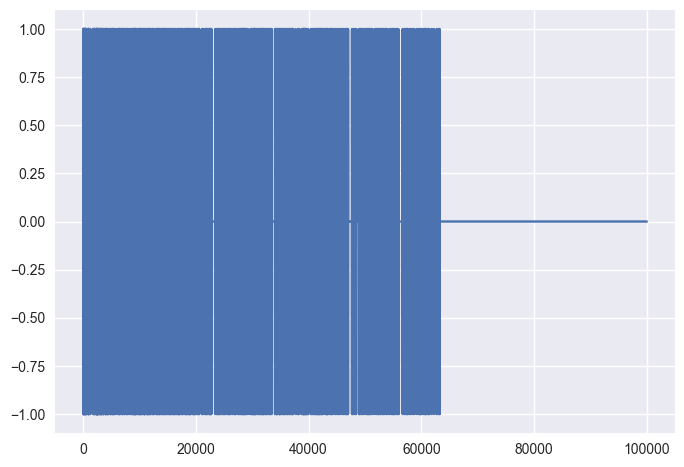

In [13]:
#| code-fold: true
#| code-summary: "Code anzeigen"

# Trainingsdatensatz erstellen

bias = np.ones(len(sepal_lengh))
input_data = [np.array((bias[i], sepal_lengh[i], sepal_width[i])) for i in range(len(sepal_lengh))]

training_data_set = [(input_data[i], colors_values[i]) for i in range(len(sepal_lengh))]

# Gewichte mit Trainingsdatensatz ermitteln

np.random.seed(30)
##Startgewichte
w = np.ones(3)/10

iterations = 100000

errors, weights = fit(iterations, training_data_set, w)

plt.plot(errors)
print('Gewichte nach Training: ', weights[len(weights)-1])

Ergebnis des Lernens darstellen

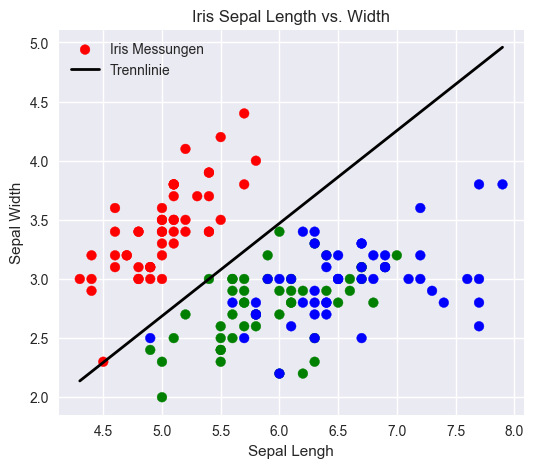

In [14]:
#| code-fold: true
#| code-summary: "Code anzeigen"

x_vals = np.linspace(min(sepal_lengh), max(sepal_lengh), 100)
w0, w1, w2 = weights[-1]
y_vals = -(w0 + w1 * x_vals) / w2

plt.style.use('seaborn-v0_8')
plt.figure(figsize=(6,5))
plt.xlabel('Sepal Lengh')
plt.ylabel('Sepal Width')
plt.title('Iris Sepal Length vs. Width')
plt.scatter(np.array(sepal_lengh), np.array(sepal_width), color = colors, label = "Iris Messungen")
plt.plot(x_vals, y_vals, color='black', linewidth=2, label="Trennlinie")
plt.legend()

### Aufgabe 2b: Iris-Arten 2

Nutzen Sie statt der sepal-Daten die petal-Daten, um ein Perzeptron zu trainieren, welches zwischen Iris-sentosa und den anderen beiden Arten unterscheiden kann!

### Aufgabe 2c: Iris-Arten 3

Versuchen Sie, mit den petal-Daten ein Perzeptron zu trainieren, welches zwischen Iris-versicolor und Iris-virginica unterscheiden kann.
Was passiert?

## Der Pinguin-Datensatz

Zu den klassischen Datensätzen gehört auch ein tierischer Datensatz, und zwar einer über Pinguine ([https://www.kaggle.com/code/parulpandey/penguin-dataset-the-new-iris](https://www.kaggle.com/code/parulpandey/penguin-dataset-the-new-iris)). Den Datensatz finden Sie [hier](Daten/Perzeptron/penguins.csv). Er enthält Messungen von Flügellängen und -breiten und Schnabellängen und -breiten von drei Pinguinarten auf drei Inseln. Darüber hinaus sind noch die Körpergewichte, das Geschlecht und das Jahr der Messung enthalten.

Wie schon beim Iris-Datensatz, werden die Daten zunächst visualisiert.

"rowid","species","island","bill_length_mm","bill_depth_mm","flipper_length_mm","body_mass_g","sex","year"



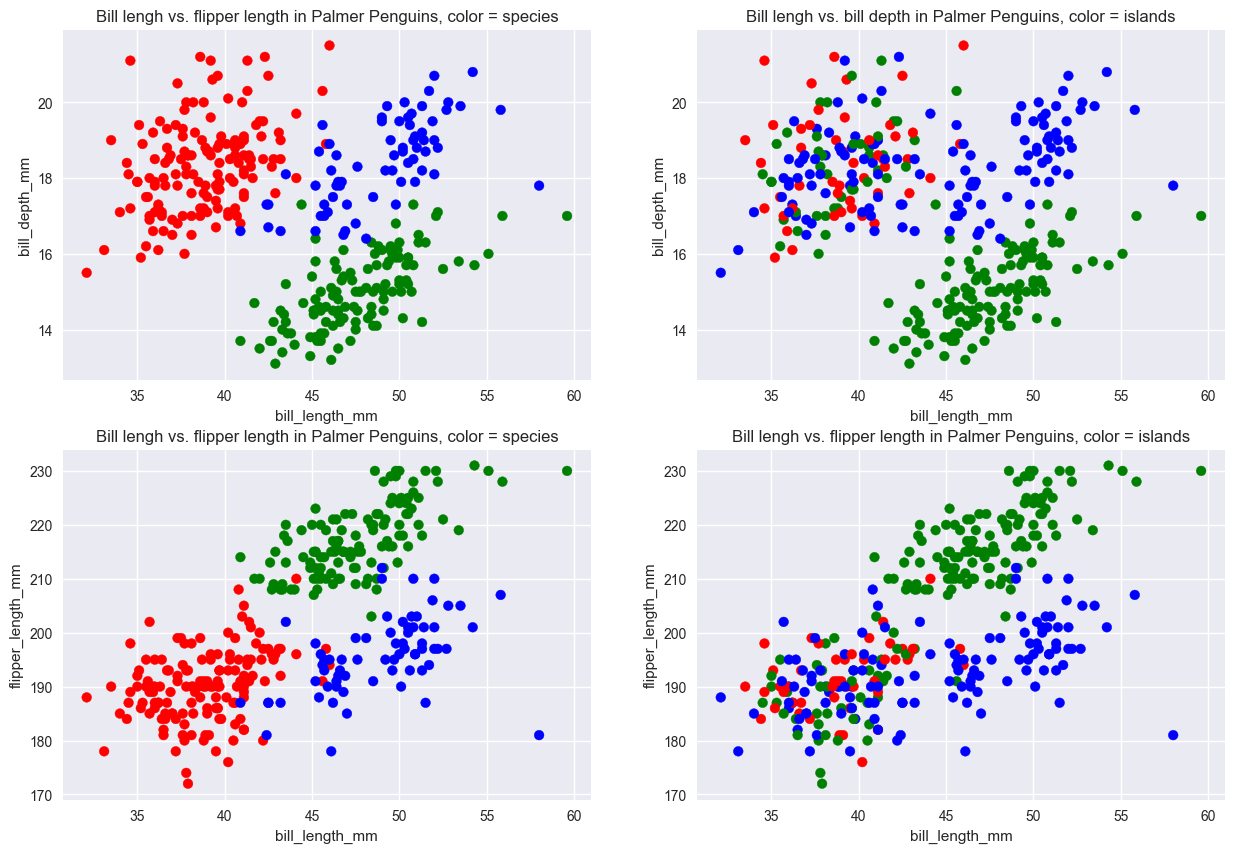

In [15]:
#| code-fold: true
#| code-summary: "Code anzeigen"

import numpy as np
import matplotlib.pyplot as plt
from random import choice  

##"rowid","species","island","bill_length_mm","bill_depth_mm","flipper_length_mm","body_mass_g","sex","year"
rowid = []
species = []
species_values = []
island = []
island_values = []
bill_length_mm = []
bill_depth_mm = []
flipper_length_mm = []
body_mass_g = []
sex = []
year = []

species_colors = {'Adelie' : 'red', 'Gentoo' : 'green' , 'Chinstrap' : 'blue'}
species_colors_values = {'Adelie' : '0', 'Gentoo' : '1' , 'Chinstrap' : '0'} 
island_colors = {'Torgersen' : 'red', 'Biscoe' : 'green' , 'Dream' : 'blue'}
island_colors_values = {'Torgersen' : '0', 'Biscoe' : '1' , 'Dream' : '0'} 

skiprow = 0

with open('Daten/Perzeptron/penguins.csv', 'r') as fobj:
    print(fobj.readline())
    for line in fobj:
        #print(line)
        words = line.rstrip().split(',')
        skiprow = 0
        for word in words:
            #print(word)
            if word == 'NA':
                skiprow = 1
                #print(word, skiprow)
        if skiprow == 0:
            rowid.append(float(words[0].strip('""')))
            species.append(species_colors[words[1].strip('""')])
            species_values.append(int(species_colors_values[words[1].strip('""')]))
            island.append(island_colors[words[2].strip('""')])
            island_values.append(int(island_colors_values[words[2].strip('""')]))
            bill_length_mm.append(float(words[3]))
            bill_depth_mm.append(float(words[4]))
            flipper_length_mm.append(float(words[5]))
            body_mass_g.append(float(words[6]))
            sex.append(words[7])
            year.append(float(words[8]))

#print(bill_length_mm)
plt.style.use('seaborn-v0_8')

fig,((ax1, ax2), (ax3, ax4)) = plt.subplots(2,2, figsize = (15,10))
ax1.set_xlabel('bill_length_mm')
ax1.set_ylabel('bill_depth_mm')
ax1.set_title('Bill lengh vs. flipper length in Palmer Penguins, color = species')
ax1.scatter(np.array(bill_length_mm), np.array(bill_depth_mm), color = species)

ax2.set_xlabel('bill_length_mm')
ax2.set_ylabel('bill_depth_mm')
ax2.set_title('Bill lengh vs. bill depth in Palmer Penguins, color = islands')
ax2.scatter(np.array(bill_length_mm), np.array(bill_depth_mm), color = island)

ax3.set_xlabel('bill_length_mm')
ax3.set_ylabel('flipper_length_mm')
ax3.set_title('Bill lengh vs. flipper length in Palmer Penguins, color = species')
ax3.scatter(np.array(bill_length_mm), np.array(flipper_length_mm), color = species)

ax4.set_xlabel('bill_length_mm')
ax4.set_ylabel('flipper_length_mm')
ax4.set_title('Bill lengh vs. flipper length in Palmer Penguins, color = islands')
ax4.scatter(np.array(bill_length_mm), np.array(flipper_length_mm), color = island)

### Aufgabe 3: Pinguine linear

Welche Merkmale lassen sich linear trennen? Welche Pinguin-Arten können mit einem einfachen Perzeptron erlernt werden?

Text(0, 0.5, 'bill_depth_mm')

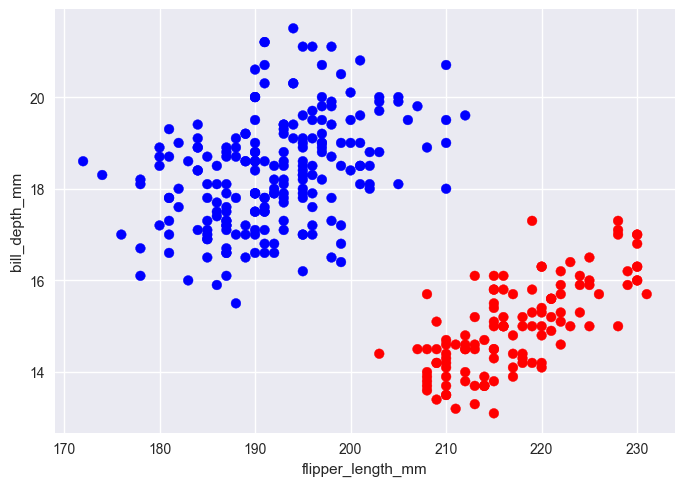

In [16]:
#| code-fold: true
#| code-summary: "Code anzeigen"

## trainingsdatensatz erstellen

bias = np.ones(len(flipper_length_mm))
input_data = [np.array((bias[i], flipper_length_mm[i], bill_depth_mm[i])) for i in range(len(flipper_length_mm))]

training_data_set = [(input_data[i], species_values[i]) for i in range(len(flipper_length_mm))]

color_new = [training_data_set[i][1] for i in range(len(training_data_set))]

for i,element in enumerate(color_new):
    if element == 0:
        #print(element,'blue')
        color_new[i] = 'blue'
    if element == 1:
        #print(element,'red')
        color_new[i] = 'red'
#print(color_new)
plt.scatter([training_data_set[i][0][1] for i in range(len(training_data_set))],[training_data_set[i][0][2] for i in range(len(training_data_set))],
          color = color_new)
plt.xlabel('flipper_length_mm')
plt.ylabel('bill_depth_mm')


# Bei Bedarf: Trainingsdatensatz ausgeben

#for i in range(len(flipper_length_mm)):
#    print(training_data_set[i])

Perzeptron erstellen

In [17]:
#| code-fold: true
#| code-summary: "Code anzeigen"

heaviside = lambda x:0 if x<0 else 1

def fit(iterations, training_data_set, w):
    errors = []
    weights = []
    
    for i in range(iterations):
        training_data = choice(training_data_set) ## zufällige Trainingsdaten (entspricht einer Zeile) aus dem Traningsdatensatz herauspicken 
        x = training_data[0]
        y = training_data[1]
                
        #ergebnis berechnen
        o = heaviside(np.dot(w,x))
        # differenz zu gewünschtem Ergebnis berechnen
        error = y - o
        #print(error)
        
        errors.append(error) ## Verlauf der Fehler protokollieren
        weights.append(w.copy())  ## Verlauf der Gewichte protokollieren
        #print(errors, weights)
        
        # Anpassung der Gewichte, immer in Schritten +- 1
        w += error*x
    return errors,weights

Perzeptron trainieren und Ergebnis ausgeben

[  -33.9   117.1 -1442.9]


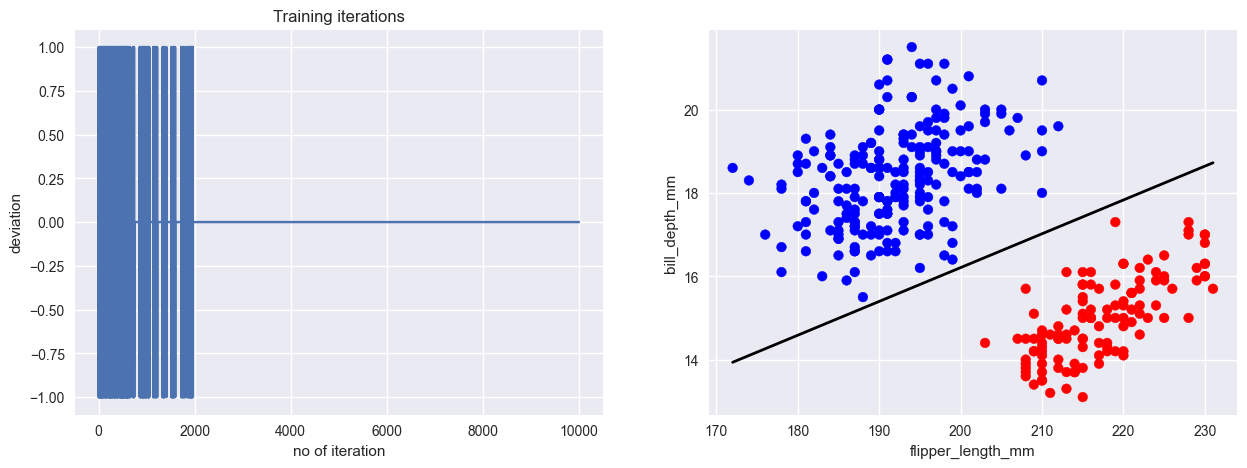

In [18]:
#| code-fold: true
#| code-summary: "Code anzeigen"

np.random.seed(12)
##Startgewichte
w = np.ones(3)/10

iterations = 10000

errors, weights = fit(iterations, training_data_set, w)

flipper_length = [x[1] for x, _ in training_data_set]
x_vals = np.linspace(min(flipper_length), max(flipper_length), 100)
w0, w1, w2 = weights[-1]
y_vals = -(w0 + w1 * x_vals) / w2

print(weights[len(weights)-1])

fig,(ax1, ax2) = plt.subplots(1,2, figsize = (15,5))
ax1.plot(errors)
ax1.set_xlabel('no of iteration')
ax1.set_ylabel('deviation')
ax1.set_title('Training iterations')
ax2.scatter([training_data_set[i][0][1] for i in range(len(training_data_set))],[training_data_set[i][0][2] for i in range(len(training_data_set))],
          color = color_new)
ax2.set_xlabel('flipper_length_mm')
ax2.set_ylabel('bill_depth_mm')
ax2.plot(x_vals, y_vals, color='black', linewidth=2, label="Trennlinie")


# Das Adaline Perzeptron 

Bislang ist das Perzeptron sehr einfach aufgebaut und es kann nur Klassen unterscheiden, die sich nicht überlappen. Die Klassen werden dann durch eine Gerade voneinander getrennt. 
Um auch Klassen trennen zu können, die sich nicht exakt trennen lassen, weil es Überlappungen zwischen den Klassen gibt, muss das Perzeptron verändert werden. Eine Möglichkeit das Adaline Perceptron (ADAptive Linear Element). Dazu wird das klassische Perzeptron un zwei Aspekte verändert:

**1. Veränderung:** Lernrate variieren

Bislang können die Gewichte nur mit Schritten von $\pm 1$ verändert werden. Dies kann aber schon zu groß sein. Daher wird die Gewichtsänderung mit einer zuvor bestimmten Lernrate $\alpha$ multipliziert.
Damit ergibt sich 
$$error = y - o$$
und 
$$\boldsymbol{w}_{neu} = \boldsymbol{w}_{alt} + error\cdot \alpha \cdot \boldsymbol{x}$$

_Anmerkung:_ Im Prinzip kann man diesen Schritt auch schon beim klassischen Perzeptron implementieren.


<figure style="text-align: center;">
    <img src="Bilder/perceptron_adaline.svg" alt="Neuron" width = 500>
    <figcaption>Aufbau des Adaline-Perzeptrons</figcaption>
</figure>


**2. Veränderung**: Veränderung der Fehlerberechnung

Bei klassischen Perzeptron erfolgt die Fehlerberechnung linear über 

$$E = y-o$$

Damit ist das Vorzeichen des Fehlers relevant für das Lernen und das Ziel ist es, die Gewichte zu finden, die $E=0$ ergeben.

Besser ist es, den quadratischen Fehler zu betrachten

$$E = \left( y-o \right)^2$$

Dann kann die Korrektur der Gewichte immer in Richtung des abnehmenden Fehlers erfolgen (_Gradient Descent_), mit dem Ziel, den Fehler zu minimieren, er muss nicht mehr exakt 0 ergeben (_Anmerkung:_ wird auch als Backpropagation bezeichnet).

Ohne die Zielsetzung zu ändern, kann noch ein Faktor 1/2 eingefügt werden. Für den Fehler E (auch Kostenfunktion genannt) ergibt sich dann

$$E = \frac{1}{2} \left( y-o \right)^2$$

Die Korrektur der Gewichte erfolgt dann immer in Richtung des negativen Gradienten der Kostenfunktion (- wegen dem negativen Gradienten)

$$\Delta w = -\frac{\partial E}{\partial w}$$

Nun kann die Stufenfunktion nicht meht als Aktivierungsfunktion verwendet werden, da sie nicht differenzierbar ist. Stattdessen wird beim Adaline Perzeptron ist die Aktivierungsfunktion einfach die Identität der linaren gewichteten Summe, also

$$z = \boldsymbol{w}\cdot\boldsymbol{x}$$
$$o = \phi(z) = id(z)$$

Damit ist

$$\Delta w = - \frac{\partial E}{\partial w} = -\frac{\partial \frac{1}{2} \left( y-o \right)^2}{\partial w} = -\frac{\partial \frac{1}{2} \left( y- \boldsymbol{w}\cdot \boldsymbol{x} \right)^2}{\partial w} $$
$$ = -\frac{1}{2} 2 \boldsymbol{x} \left( y-o \right) = - \boldsymbol{x} \left( y-o \right)$$

Die Ausgabefunktion kann dann wieder eine Stufenfunktion sein.


## Unterschied zwischen klassischem Perzeptron und Adaline-Perzeptron

Das klassische Perzeptron und das Adaline Perzeptron nutzen beide lineare Modelle, allerdings unterscheidet sich die Lernweise

### Klassisches Perzeptron

Das klassische Perzeptron ist ein reiner Klassifikator.  
Es trifft eine Entscheidung anhand des Vorzeichens der linearen Funktion:

$$o = \text{sign}(w \cdot x)$$

Die Gewichte werden nur dann angepasst, wenn ein Trainingsbeispiel falsch klassifiziert wurde.

$$ w += error \cdot x \cdot alpha$$
Korrekt klassifizierte Punkte haben keinen Einfluss auf das Lernen.

### Adaline-Perzeptron

Adaline verwendet ebenfalls ein lineares Modell, interpretiert dessen Ausgabe jedoch kontinuierlich:

$z=w⋅x$

$o = id(z)$

Statt einer Klassifikationsregel wird eine quadratische Fehlerfunktion minimiert:

$E= \frac{1}{2}(y−o)^2$

Die Gewichte werden per Gradient Descent angepasst:

$w += \alpha \, (y - w \cdot x) \, x$


Adaline ist damit eine lineare Regression, auch wenn die Zielwerte oft −1 und +1 sind.

Die spätere Klassifikation ist nur ein Nebenprodukt und nicht Teil des Optimierungsziels.

|   klassisches Perzeptron |    Adaline Perzeptron |
| ------------------------ | --------------------- |
| lernt explizit eine Trennlinie | konvexes Optimierungsproblem |
| konvergiert, wenn die Daten linear trennbar sind | stabile Konvergenz |
| keine Wahrscheinlichkeiten | lernt eine Regressionsgerade |
| instabil bei nicht trennbaren Daten | keine explizite Optimierung der Klassengrenze |


## Implementierung in den Code


Am Code müssen also folgende Änderungen vorgenommen werden:

* Die Berechnung des Fehlers erfolgt durch $E = \frac{1}{2}\left(y - \boldsymbol{w}\cdot\boldsymbol{x}\right)^2$
* Die Anpassung der zum Fehler beitragenden Gewichte erfolgt durch $\Delta \boldsymbol{w} = \left(y - \boldsymbol{w}\cdot\boldsymbol{x}\right)\cdot\alpha\cdot \boldsymbol{x}$

Adaline versucht also, eine Gerade zu finden, die den Zielwert (den quadratischen Fehler) minimiert. 
Für die Konvergenz ist es daher hilfreich, wenn die Klassen symmetrisch getrennt werden, in unserem Fall also

Iris-setosa --> -1
Iris-versicolor --> 1
Iris-virginica --> 1

oder bei den Pinguinen

Adelie --> -1
Gentoo --> 1
Chinstrap --> -1


## Beispiel 4: Adaline mit Iris

[(array([1. , 1.4, 0.2]), -1), (array([1. , 1.4, 0.2]), -1), (array([1. , 1.3, 0.2]), -1), (array([1. , 1.5, 0.2]), -1), (array([1. , 1.4, 0.2]), -1), (array([1. , 1.7, 0.4]), -1), (array([1. , 1.4, 0.3]), -1), (array([1. , 1.5, 0.2]), -1), (array([1. , 1.4, 0.2]), -1), (array([1. , 1.5, 0.1]), -1), (array([1. , 1.5, 0.2]), -1), (array([1. , 1.6, 0.2]), -1), (array([1. , 1.4, 0.1]), -1), (array([1. , 1.1, 0.1]), -1), (array([1. , 1.2, 0.2]), -1), (array([1. , 1.5, 0.4]), -1), (array([1. , 1.3, 0.4]), -1), (array([1. , 1.4, 0.3]), -1), (array([1. , 1.7, 0.3]), -1), (array([1. , 1.5, 0.3]), -1), (array([1. , 1.7, 0.2]), -1), (array([1. , 1.5, 0.4]), -1), (array([1. , 1. , 0.2]), -1), (array([1. , 1.7, 0.5]), -1), (array([1. , 1.9, 0.2]), -1), (array([1. , 1.6, 0.2]), -1), (array([1. , 1.6, 0.4]), -1), (array([1. , 1.5, 0.2]), -1), (array([1. , 1.4, 0.2]), -1), (array([1. , 1.6, 0.2]), -1), (array([1. , 1.6, 0.2]), -1), (array([1. , 1.5, 0.4]), -1), (array([1. , 1.5, 0.1]), -1), (array([1

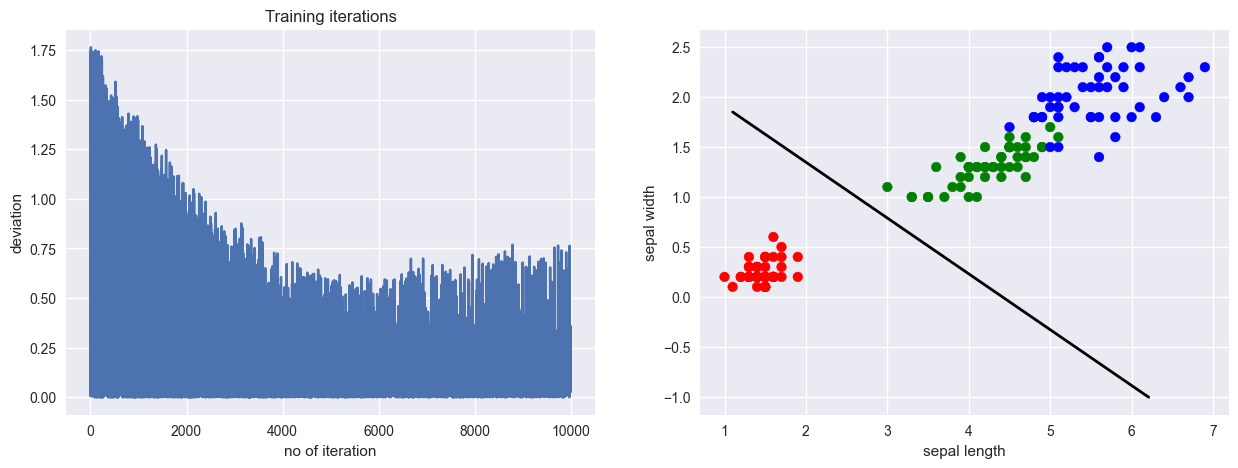

In [19]:
#| code-fold: true
#| code-summary: "Code anzeigen"

import numpy as np
import matplotlib.pyplot as plt
from random import choice  

heaviside = lambda x:0 if x<0 else 1

def fit(iterations, training_data_set, w):
    errors = []
    weights = []
    
    for i in range(iterations):
        ## zufällige Trainingsdaten (entspricht einer Zeile) 
        # aus dem Traningsdatensatz herauspicken
        training_data = choice(training_data_set)  
        x = training_data[0]
        y = training_data[1]
                
        # MSE zu gewünschtem Ergebnis berechnen
        error = (y - np.dot(w,x))**2
        
        errors.append(error) ## Verlauf der Fehler protokollieren
        weights.append(w.copy())  ## Verlauf der Gewichte protokollieren
        #print(errors, weights)
        
        # Anpassung der Gewichte
        w += (y - np.dot(w,x))*alpha*x
    return errors,weights


sepal_lengh = []
sepal_width = []
petal_length = []
petal_width = []
colors = []
colors_values = []
iris_colors = {'Iris-setosa' : 'red', 'Iris-versicolor' : 'green' , 'Iris-virginica' : 'blue'}
iris_colors_values = {'Iris-setosa' : '-1', 'Iris-versicolor' : '1' , 'Iris-virginica' : '1'}  ## Klassen symmetrisch erstellen

with open('Daten/Perzeptron/iris.csv', 'r') as fobj:
    for line in fobj:
        words = line.rstrip().split(',')
        if len(words) != 5:
            continue
        #print(words)
        sepal_lengh.append(float(words[0]))
        sepal_width.append(float(words[1]))
        petal_length.append(float(words[2]))
        petal_width.append(float(words[3]))
        colors.append(iris_colors[words[4]])
        colors_values.append(int(iris_colors_values[words[4]]))


# Trainingsdatensatz erstellen

bias = np.ones(len(petal_length))
input_data = [np.array((bias[i], petal_length[i], petal_width[i])) for i in range(len(petal_length))]

training_data_set = [(input_data[i], colors_values[i]) for i in range(len(petal_length))]
print(training_data_set)

# Gewichte mit Trainingsdatensatz ermitteln

np.random.seed(30)
##Startgewichte
w = np.ones(3)/10

# Lernrate festlegen
alpha = 0.001

iterations = 10000

errors, weights = fit(iterations, training_data_set, w)

#print(weights[len(weights)-1])

x_vals = np.linspace(1.1*min(petal_length), 0.9*max(petal_length), 100)
w0, w1, w2 = weights[-1]
y_vals = -(w0 + w1 * x_vals) / w2

fig,(ax1, ax2) = plt.subplots(1,2, figsize = (15,5))
ax1.plot(errors)
ax1.set_xlabel('no of iteration')
ax1.set_ylabel('deviation')
ax1.set_title('Training iterations')
ax2.scatter(np.array(petal_length), np.array(petal_width), color = colors, label = "Iris Messungen")
ax2.set_xlabel('sepal length')
ax2.set_ylabel('sepal width')
ax2.plot(x_vals, y_vals, color='black', linewidth=2, label="Trennlinie")

file = open('output/weights_verbessertes_perzeptron1.csv', 'w')
for i in range(len(weights)):
    file.write(str(weights[i][0]) + ',' + str(weights[i][1]) + ',' + str(weights[i][2]) + '\n')
file.close()

## Beispiel 5: Adaline mit Pinguinen

Hier werden Pinguine verschiedener Inseln klassifiziert

Torgersen und Dream --> -1
Biscoe --> 1 

"rowid","species","island","bill_length_mm","bill_depth_mm","flipper_length_mm","body_mass_g","sex","year"



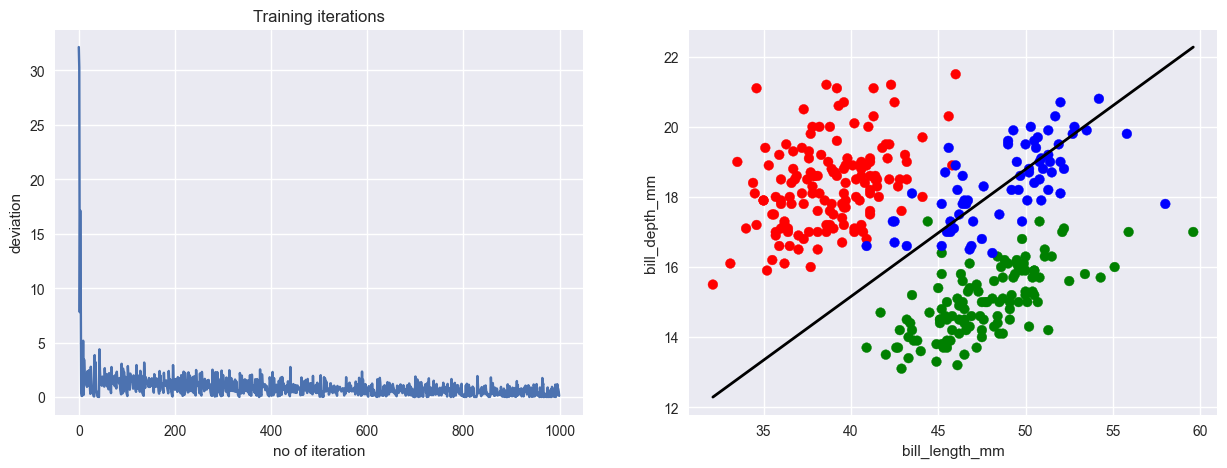

In [20]:
#| code-fold: true
#| code-summary: "Code anzeigen"

import numpy as np
import matplotlib.pyplot as plt
from random import choice  

heaviside = lambda x:0 if x<0 else 1

def fit(iterations, training_data_set, w):
    errors = []
    weights = []
    
    for i in range(iterations):
        ## zufällige Trainingsdaten (entspricht einer Zeile) 
        # aus dem Traningsdatensatz herauspicken
        training_data = choice(training_data_set)  
        x = training_data[0]
        y = training_data[1]
                
        # MSE zu gewünschtem Ergebnis berechnen
        error = (y - np.dot(w,x))**2
        
        errors.append(error) ## Verlauf der Fehler protokollieren
        weights.append(w.copy())  ## Verlauf der Gewichte protokollieren
        #print(errors, weights)
        
        # Anpassung der Gewichte
        w += (y - np.dot(w,x))*alpha*x
    return errors,weights


##"rowid","species","island","bill_length_mm","bill_depth_mm","flipper_length_mm","body_mass_g","sex","year"
rowid = []
species = []
species_values = []
island = []
island_values = []
bill_length_mm = []
bill_depth_mm = []
flipper_length_mm = []
body_mass_g = []
sex = []
year = []

species_colors = {'Adelie' : 'red', 'Gentoo' : 'green' , 'Chinstrap' : 'blue'}
species_colors_values = {'Adelie' : '-1', 'Gentoo' : '1' , 'Chinstrap' : '1'} 
island_colors = {'Torgersen' : 'red', 'Biscoe' : 'green' , 'Dream' : 'blue'}
island_colors_values = {'Torgersen' : '-1', 'Biscoe' : '1' , 'Dream' : '-1'} 

skiprow = 0

with open('Daten/Perzeptron/penguins.csv', 'r') as fobj:
    print(fobj.readline())
    for line in fobj:
        #print(line)
        words = line.rstrip().split(',')
        skiprow = 0
        for word in words:
            #print(word)
            if word == 'NA':
                skiprow = 1
                #print(word, skiprow)
        if skiprow == 0:
            rowid.append(float(words[0].strip('""')))
            species.append(species_colors[words[1].strip('""')])
            species_values.append(int(species_colors_values[words[1].strip('""')]))
            island.append(island_colors[words[2].strip('""')])
            island_values.append(int(island_colors_values[words[2].strip('""')]))
            bill_length_mm.append(float(words[3]))
            bill_depth_mm.append(float(words[4]))
            flipper_length_mm.append(float(words[5]))
            body_mass_g.append(float(words[6]))
            sex.append(words[7])
            year.append(float(words[8]))

# Trainingsdatensatz erstellen

bias = np.ones(len(bill_length_mm))

input_data = [np.array((bias[i], bill_length_mm[i], bill_depth_mm[i])) for i in range(len(bill_length_mm))]

training_data_set = [(input_data[i], species_values[i])
                     for i in range(len(bill_length_mm))]


# Gewichte mit Trainingsdatensatz ermitteln

np.random.seed(30)
##Startgewichte
w = np.ones(3)/10

# Lernrate festlegen
alpha = 0.0001

iterations = 1000

errors, weights = fit(iterations, training_data_set, w)


x_vals = np.linspace(min(bill_length_mm), max(bill_length_mm), 100)
w0, w1, w2 = weights[-1]
y_vals = -(w0 + w1 * x_vals) / w2

fig,(ax1, ax2) = plt.subplots(1,2, figsize = (15,5))
ax1.plot(errors)
ax1.set_xlabel('no of iteration')
ax1.set_ylabel('deviation')
ax1.set_title('Training iterations')
ax2.scatter(np.array(bill_length_mm), np.array(bill_depth_mm), color = species, label = "Pinguin Messungen")
ax2.set_xlabel('bill_length_mm')
ax2.set_ylabel('bill_depth_mm')
ax2.plot(x_vals, y_vals, color='black', linewidth=2, label="Trennlinie")

file = open('output/weights_verbessertes_perzeptron1.csv', 'w')
for i in range(len(weights)):
    file.write(str(weights[i][0]) + ',' + str(weights[i][1]) + ',' + str(weights[i][2]) + '\n')
file.close()

## Aufgabe 4a: Lernrate variieren

Variieren Sie die Lernrate und die Anzahl der Iterationen. Wie wirken sich diese Werte auf das Ergebnis aus?

## Aufgabe 4b: Weitere Klassen

Versuchen Sie weitere Klassifizierungen von Irisen und Pinguinen zu erlernen. Was klappt gut? Was funktioniert nicht so gut?

# Das moderne Perzeptron

<figure style="text-align: center;">
    <img src="Bilder/perceptron_modern.svg" alt="Neuron" width = 500>
    <figcaption>Aufbau des modernen Perzeptrons</figcaption>
</figure>

Das moderne Perzeptron stellt eine Erweiterung des Adaline Perzeptrons um eine beliebige Aktivierungsfunktion dar.
Durch Anwendung der Kettenregel ergibt sich, dass die Gewichtsänderung vom Fehlerterm $\left( \phi \left( z \right) - y \right)$ sowie von der Ableitung der Aktivierungsfunktion abhängt.
Beim modernen Perzeptron ergibt sich somit die Veränderung der Gewichte über

$$\Delta w = - \frac{\partial E}{\partial w} = - \frac{\partial \frac{1}{2} \left( y - o\right)^2}{\partial w} = - \frac{\partial \frac{1}{2} \left( y - \phi(z)\right)^2}{\partial w} $$
$$= - \frac{1}{2} 2 \left( y - \phi(z)\right) \frac{\partial \phi(z)}{\partial w} = \left(\phi(z) - y\right) \frac{\partial \phi(z)}{\partial w} $$

mit $z = \boldsymbol{w}\cdot\boldsymbol{x}$.

Das Verfahren wird auch als Backpropagation bezeichnet. Die Backpropagation bildet die Grundlage für das Lernen in mehrschichtigen neuronalen Netzen.

## Beispiele für Aktivierungsfunktionen

Beispiele für Aktivierungsfunktionen sind

- TanH: $\phi(\boldsymbol{x}, \boldsymbol{w}) = \tanh \left( \boldsymbol{w}\cdot\boldsymbol{x} \right)$
- ReLu: $\phi(\boldsymbol{x}, \boldsymbol{w}) = max \left(0, \boldsymbol{w}\cdot\boldsymbol{x} \right)$
- Sigmoid $\phi(\boldsymbol{x}, \boldsymbol{w}) = \frac{1}{1+ e^{-\boldsymbol{w}\cdot\boldsymbol{x}}}$

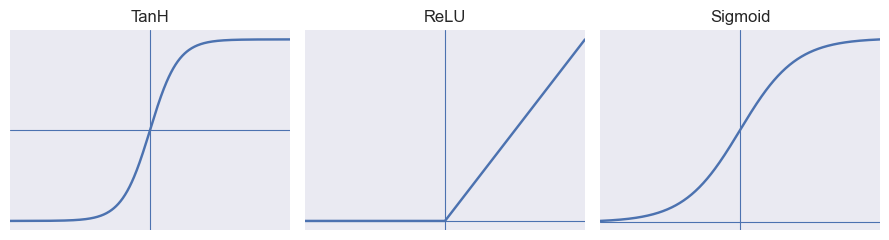

In [21]:
#| code-fold: true
#| code-summary: "Code anzeigen"

import numpy as np
import matplotlib.pyplot as plt

x = np.linspace(-5, 5, 500)

# Aktivierungsfunktionen
tanh = np.tanh(x)
relu = np.maximum(0, x)
sigmoid = 1 / (1 + np.exp(-x))

fig, axes = plt.subplots(1, 3, figsize=(9, 2.5))

functions = [
    (tanh, "TanH"),
    (relu, "ReLU"),
    (sigmoid, "Sigmoid")
]

for ax, (y, title) in zip(axes, functions):
    ax.plot(x, y)
    ax.axhline(0, linewidth=0.8)
    ax.axvline(0, linewidth=0.8)
    ax.set_title(title)
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_xlim(-5, 5)

plt.tight_layout()
plt.show()


## Das moderne Perzeptron und die Iris-Daten

Daten einlesen:

[(array([1. , 5.1, 3.5]), -1), (array([1. , 4.9, 3. ]), -1), (array([1. , 4.7, 3.2]), -1), (array([1. , 4.6, 3.1]), -1), (array([1. , 5. , 3.6]), -1), (array([1. , 5.4, 3.9]), -1), (array([1. , 4.6, 3.4]), -1), (array([1. , 5. , 3.4]), -1), (array([1. , 4.4, 2.9]), -1), (array([1. , 4.9, 3.1]), -1), (array([1. , 5.4, 3.7]), -1), (array([1. , 4.8, 3.4]), -1), (array([1. , 4.8, 3. ]), -1), (array([1. , 4.3, 3. ]), -1), (array([1. , 5.8, 4. ]), -1), (array([1. , 5.7, 4.4]), -1), (array([1. , 5.4, 3.9]), -1), (array([1. , 5.1, 3.5]), -1), (array([1. , 5.7, 3.8]), -1), (array([1. , 5.1, 3.8]), -1), (array([1. , 5.4, 3.4]), -1), (array([1. , 5.1, 3.7]), -1), (array([1. , 4.6, 3.6]), -1), (array([1. , 5.1, 3.3]), -1), (array([1. , 4.8, 3.4]), -1), (array([1., 5., 3.]), -1), (array([1. , 5. , 3.4]), -1), (array([1. , 5.2, 3.5]), -1), (array([1. , 5.2, 3.4]), -1), (array([1. , 4.7, 3.2]), -1), (array([1. , 4.8, 3.1]), -1), (array([1. , 5.4, 3.4]), -1), (array([1. , 5.2, 4.1]), -1), (array([1. ,

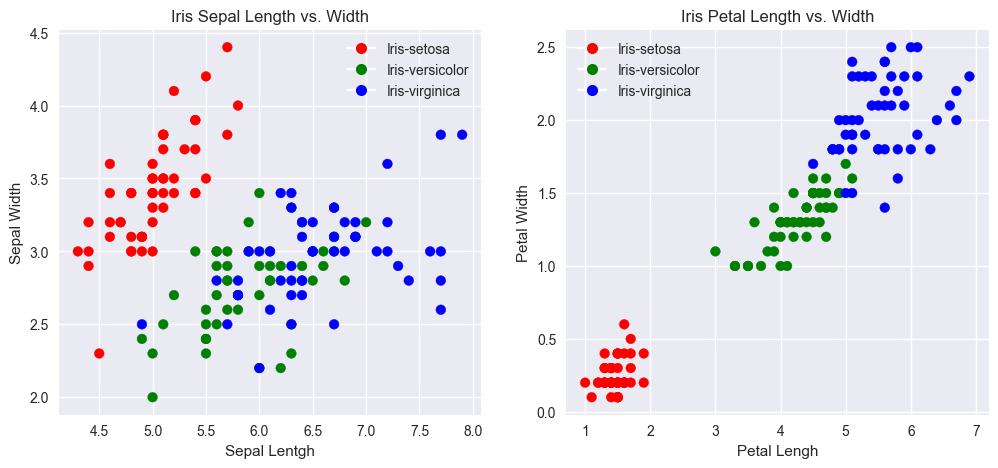

In [22]:
#| code-fold: true
#| code-summary: "Code anzeigen"

import numpy as np
import matplotlib.pyplot as plt
from random import choice  ##The choice() method returns a randomly selected element from the specified sequence.

sepal_length = []
sepal_width = []
petal_length = []
petal_width = []
colors = []
colors_values = []
iris_colors = {'Iris-setosa' : 'red', 'Iris-versicolor' : 'green' , 'Iris-virginica' : 'blue'}
iris_colors_values = {'Iris-setosa' : '-1', 'Iris-versicolor' : '1' , 'Iris-virginica' : '1'}  ## Anmerkung: rot und blau/gruen lassen sich linear trennen, blau und gruen nicht

with open('Daten/Perzeptron/iris.csv', 'r') as fobj:
    for line in fobj:
        words = line.rstrip().split(',')
        if len(words) != 5:
            continue
        #print(words)
        sepal_length.append(float(words[0]))
        sepal_width.append(float(words[1]))
        petal_length.append(float(words[2]))
        petal_width.append(float(words[3]))
        colors.append(iris_colors[words[4]])
        colors_values.append(int(iris_colors_values[words[4]]))

bias = np.ones(len(sepal_width))
input_data = [np.array((bias[i], sepal_length[i], sepal_width[i])) for i in range(len(sepal_length))]

training_data_set = [(input_data[i], colors_values[i]) for i in range(len(sepal_length))]

print(training_data_set)

X = [x for x, y in training_data_set]
y = [y for x, y in training_data_set]

print(X)
print(y)

plt.style.use('seaborn-v0_8')
plt.figure(figsize=(12,5))
ax1 = plt.subplot(1,2,1)
ax1.set_xlabel('Sepal Lentgh')
ax1.set_ylabel('Sepal Width')
ax1.set_title('Iris Sepal Length vs. Width')
ax1.scatter(np.array(sepal_length), np.array(sepal_width), color = colors)
ax2 = plt.subplot(1,2,2)
ax2.set_xlabel('Petal Lengh')
ax2.set_ylabel('Petal Width')
ax2.set_title('Iris Petal Length vs. Width')
ax2.scatter(np.array(petal_length), np.array(petal_width), color = colors)

from matplotlib.lines import Line2D

legend_elements = [
    Line2D([0], [0], marker='o', color='w', label='Iris-setosa',
           markerfacecolor='red', markersize=8),
    Line2D([0], [0], marker='o', color='w', label='Iris-versicolor',
           markerfacecolor='green', markersize=8),
    Line2D([0], [0], marker='o', color='w', label='Iris-virginica',
           markerfacecolor='blue', markersize=8)
]

ax1.legend(handles=legend_elements)
ax2.legend(handles=legend_elements)

### Perzeptron mit tanh-Aktivierungsfunktion

Zum besseren Verständnis des Verfahrens der Backpropagation wird diese beispielhaft für ein Perzeptron mit tanh als Aktivierungsfunktion vorgerechnet. Wird eine andere Aktivierungsfunktion verwendet, ist das Verfahren analog durchzuführen.

Die Funktionskette des Modells beschreibt, wie die einzelnen Rechenschritte im Modell durchlaufen werden. In diesem Fall ist die Funktionskette gegeben durch

$$
w \rightarrow z \rightarrow a = \phi \rightarrow o \rightarrow E
$$

mit

| Schritt | Ausdruck | Beschreibung |
|--------|----------|--------------|
| Eingabe → Gewichtung | $z = x \cdot w$ | Gewichtete Summe der Eingabedaten |
| Aktivierung | a = $\phi(z) = \tanh(z)$ | Nichtlineare Aktivierungsfunktion, hier tanh |
| Ausgabe | $o = id(a)$ | Lineare Outputfunktion |
| Fehler | $E = \frac{1}{2}(y - o)^2$ | Quadratische Fehlerfunktion für Gradientenabstieg |

Zur Berechnung des Gradienten wird die Kettenregel verwendet.

$$
\frac{\partial E}{\partial w}
=
\frac{\partial E}{\partial o}
\cdot
\frac{\partial o}{\partial a}
\cdot
\frac{\partial a}{\partial z}
\cdot
\frac{\partial z}{\partial w}
=
\frac{\partial E}{\partial a}
\cdot
\frac{\partial a}{\partial z}
\cdot
\frac{\partial z}{\partial w}
$$


Die einzelnen Ableitungen, die zur gesamten Ableitung mit der Kettenregel beitragen sind die

Fehlerfunktion:

$$
\frac{\partial E}{\partial a}
=
-(y-a)
$$

Aktivierungsfunktion:

$$
\frac{\partial a}{\partial z}
=
\frac{\partial}{\partial z}\tanh(z)
=
1-\tanh^2(z)
$$

gewichtete Summe:

$$
\frac{\partial z}{\partial w}
=
\frac{\partial}{\partial w}(x \cdot w)
=
x
$$


Damit ergibt sich der Gradient

$$
\frac{\partial E}{\partial w}
=
-(y-a)(1-\tanh^2(z))x
$$

mit

$$
a = \tanh(z), \quad z = x \cdot w
$$

Zusammenfassung der Vorgehensweise:

Der Gradient gibt die Richtung an, in der die Gewichte angepasst werden müssen, um den Fehler zu minimieren. Durch Multiplikation mit einer Lernrate können die Gewichte schrittweise in Richtung des negativen Gradienten aktualisiert werden. Dieses Vorgehen wird iterativ für alle Trainingsdaten des Iris-Datensatzes wiederholt, bis das Modell eine ausreichend gute Approximation erreicht.


Finale Gewichte: [-11.2906214    5.04876714  -5.0463563 ]


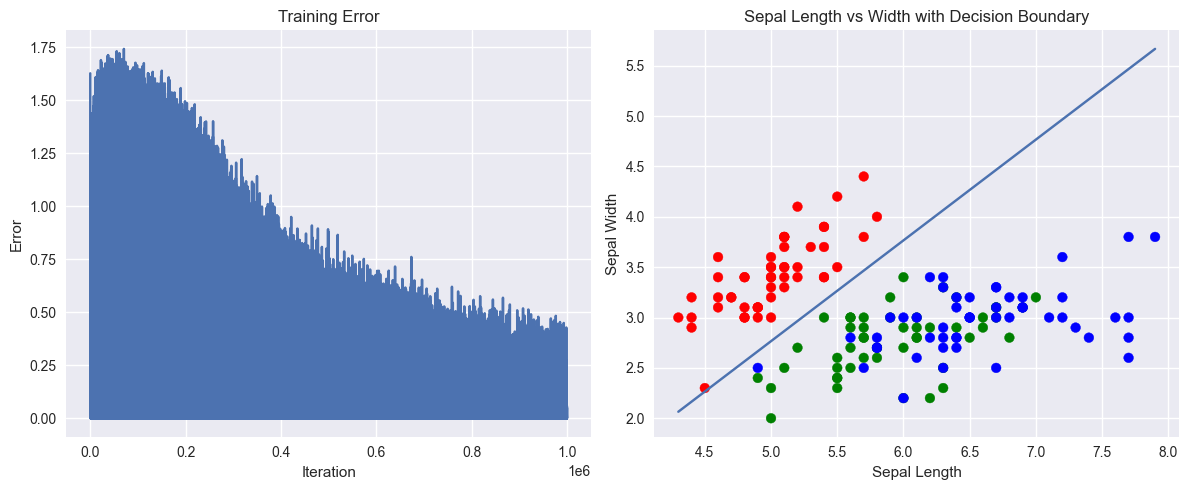

In [23]:
#| code-fold: true
#| code-summary: "Code anzeigen"

import numpy as np
import matplotlib.pyplot as plt
from random import choice

def tanh(z):
    return np.tanh(z)

def dtanh(z):
    return 1.0 - np.tanh(z)**2

def errorfunction(y, o):
    return 0.5 * (y - o)**2

def forwards(X, w):
    z = np.dot(X, w)
    o = tanh(z)
    return o

def weight_gradient(X, y, w):
    z = np.dot(X, w)
    o = tanh(z)
    grad = (o - y) * dtanh(z) * X
    return grad

def fit(iterations, training_data_set, w, alpha=0.01):
    errors = []
    weights = []

    for i in range(iterations):
        x, y = choice(training_data_set)

        o = forwards(x, w)
        error = errorfunction(y, o)

        errors.append(error)
        weights.append(w.copy())

        grad = weight_gradient(x, y, w)
        w -= alpha * grad   # wichtig: Minus!

    return errors, weights, w

#np.random.seed(30)
#w = np.random.rand(3)
##Startgewichte
w = np.ones(3)/10
errors, weights, w = fit(1000000, training_data_set, w)


# grafische Darstellung der Ergebnisse 

plt.figure(figsize=(12,5))

ax1 = plt.subplot(1,2,1)
ax1.plot(errors)
ax1.set_title("Training Error")
ax1.set_xlabel("Iteration")
ax1.set_ylabel("Error")

ax2 = plt.subplot(1,2,2)
ax2.scatter(sepal_length, sepal_width, color=colors)
ax2.set_title("Sepal Length vs Width with Decision Boundary")
ax2.set_xlabel("Sepal Length")
ax2.set_ylabel("Sepal Width")

# Trennlinie berechnen
x_vals = np.linspace(min(sepal_length), max(sepal_length), 100)
y_vals = -(w[0] + w[1]*x_vals) / w[2]

ax2.plot(x_vals, y_vals)

plt.tight_layout()

print("Finale Gewichte:", w)

<!--

## Perzeptron mit tanh-Aktivierungsfunktion und nichtlinearer Outputfunktion

Theoretisch könnte man auch noch eine nichtlineare Aktivierungsfunktion wählen, wie beispielsweise sigmoid.
Macht das Model aber unnötig kompliziert und langsam.

Würde man das machen, dann wäre die Funktionskette

Die Funktionskette des Modells ist

$$w \rightarrow z \rightarrow a \rightarrow o \rightarrow E$$


Damit Kettenregel für die Funktionskette

$$\frac{\partial E}{\partial w}
=
\frac{\partial E}{\partial o}
\cdot
\frac{\partial o}{\partial a}
\cdot
\frac{\partial a}{\partial z}
\cdot
\frac{\partial z}{\partial w}$$


Hier mit Funktionen 

$$a = \phi(z) = \tanh(z)$$
$$o = \alpha(a) = \text{sigmoid}(a) $$

Damit sind die Ableitungen

$$
\frac{\partial \tanh(z)}{\partial z} = 1 - \tanh(z)^2
$$

$$
\text{sigmoid}(a) = \frac{1}{1 + e^{-a}}
$$

$$
\frac{\partial \text{sigmoid}(a)}{\partial a} = \text{sigmoid}(a) \cdot \left(1 - \text{sigmoid}(a) \right)
$$


und die Kettenregel ergibt

$$\frac{\partial E}{\partial o} = \frac{\partial}{\partial w} \frac{1}{2} \left(y - o \right)^2 = -\left(y - o \right)$$

$$\frac{\partial o}{\partial a} = \frac{\partial}{\partial a} \frac{1}{1 + e^{-a}}= \text{sigmoid}(a) \cdot \left(1 - \text{sigmoid}(a) \right)$$

$$\frac{\partial a}{\partial z} = \frac{\partial }{\partial z} \tanh(z) = 1 - \tanh(z)^2$$

$$\frac{\partial z}{\partial w} = \frac{\partial}{\partial w} x\cdot w = x$$

Damit ist der Gradient

$$\frac{\partial E}{\partial w} = -\left(y - o \right) \text{sigmoid}^\prime (a) \tanh^\prime(z) \cdot x$$

-->

# Das Perzeptron in scikidlearn und Pytorch

Bislang wurden das Perzeptron selbst programmiert. Natürlich gibt es auch Python-Pakete, die das Perzeptron bereits enthalten. Ein Beispiel ist das bekannte Python-Paket [Scikid-learn](https://scikit-learn.org/stable/), welches auch eine Klasse für das [Perzeptron](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.Perceptron.html) enthält. Ein weiteres bekanntes Paket für Machine Learning Anwendungen in Python ist das Paket [PyTorch](https://pytorch.org/).

## Das Perzeptron in Scikit-learn

In Scikit-learn wird es über die Klasse sklearn.linear_model.Perceptron bereitgestellt.
Importiert wird es über

```
from sklearn.linear_model import Perceptron

model = Perceptron()
```

Optionale Parameter sind

```
model = Perceptron(max_iter=1000, eta0=0.1, random_state=42)
```

dabei ist

|Parameter | Beschreibung |
|--------- | ------------ |
|max_iter: |Anzahl der Trainingsdurchläufe |
|eta0: |Lernrate|
|random_state: |Reproduzierbarkeit|

Die wichtigsten Funktionen der klasse sind:

Zum Training des Perzeptrons
```
model.fit(X_train, y_train)
```

dabei sind X_train die Inputdaten und y_train die Zielwerte.

Zum treffen von Vorhersagen mit dem trainierten Modell
```
y_pred = model.predict(X_test)
```

Das moderne Perzeptron wird in Scikit-Learn nicht separat als Objekt modelliert, sondern über ein mehrschichtiges Netz abgebildet. 

```
from sklearn.neural_network import MLPClassifier

model = MLPClassifier(
    hidden_layer_sizes=(1,),   # 1 Hidden Layer mit 1 Neuron
    activation='tanh',          # Aktivierungsfunktion
    solver='gd',              # Optimierungsverfahren
    max_iter=1000
)
```


## Perzeptron in PyTorch

In PyTorch baut man ein Perzeptron selbst als lineares Modell mit nn.Linear, definiert eine Verlustfunktion und trainiert es über Backpropagation und einen Optimierer wie SGD. Dadurch ist man flexibler als in Scikit-Learn, muss aber mehr Schritte explizit implementieren.

## Aufgabe 5: Aktivierungsfunktion variieren

Nutzen Sie alternative Aktivierungsfunktionen, wie sigmoid oder relu und berechnen Sie den Gradientenabstieg mit Hilfe der Kettenregel. Wie wirken sich diese auf das Ergebnis aus?

# Abschlussprojekt Perzeptron: Motorbelastung erkennen



Bei einem Motor messen Sie Spannung und Stromaufnahme. Anhand der Daten sollen Sie ein Perzeptron trainineren, welches erkennt, ob der Motor belastet oder unbelastet läuft.

_Anmerkungen:_

- Da die Daten linear trennbar sind, funktioniert das klassische Perzeptron besser.
- Da die Werte von Spannung und Strom sehr unterschiedlich sind, empfielt sich eine Normalisierung der Daten

[3.0, 3.5, 4.0, 4.5, 5.0, 5.5, 6.0, 3.0, 3.5, 4.0, 4.5, 5.0, 5.5, 6.0, 3.0, 3.5, 4.0, 4.5, 5.0, 5.5, 6.0, 3.0, 3.5, 4.0, 4.5, 5.0, 5.5, 6.0]
[62.0, 63.0, 65.0, 67.0, 68.0, 70.0, 71.0, 80.0, 87.0, 92.0, 100.0, 104.0, 110.0, 130.0, 84.0, 91.0, 99.0, 105.0, 110.0, 120.0, 130.0, 75.0, 80.0, 84.0, 87.0, 87.0, 89.0, 89.0]
['1', '1', '1', '1', '1', '1', '1', '2', '2', '2', '2', '2', '2', '2', '3', '3', '3', '3', '3', '3', '3', '4', '4', '4', '4', '4', '4', '4']


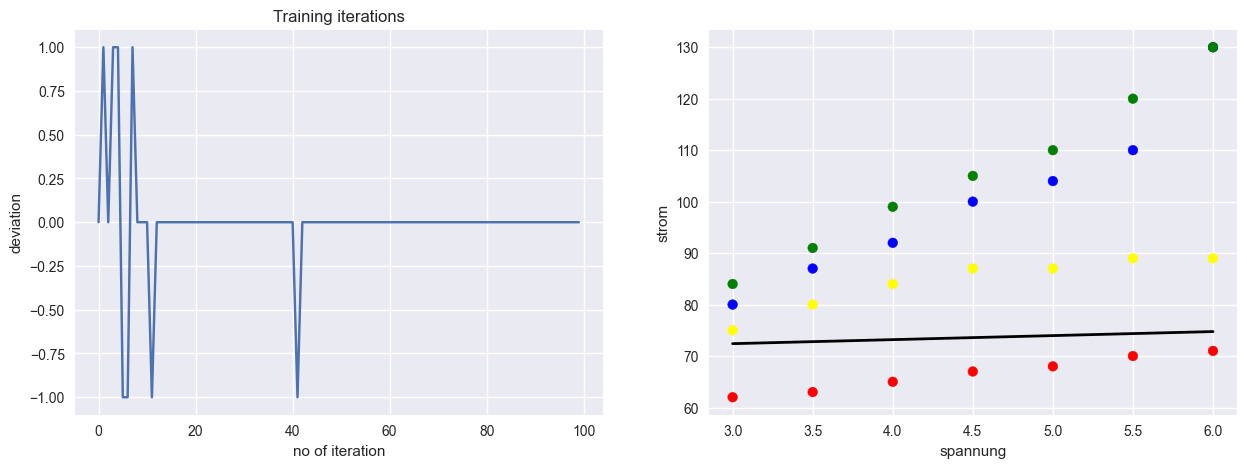

In [24]:
#| include: false

import numpy as np
import matplotlib.pyplot as plt
from random import choice  
heaviside = lambda x:0 if x<0 else 1

#einfaches Perzeptron
def fit(iterations, training_data_set, w):
    errors = []
    weights = []
    
    for i in range(iterations):
        training_data = choice(training_data_set) ## zufällige Trainingsdaten (entspricht einer Zeile) aus dem Traningsdatensatz herauspicken 
        x = training_data[0]
        y = training_data[1]
                
        #ergebnis berechnen
        o = heaviside(np.dot(w,x))
        # differenz zu gewünschtem Ergebnis berechnen
        error = y - o
        #print(error)
        
        errors.append(error) ## Verlauf der Fehler protokollieren
        weights.append(w.copy())  ## Verlauf der Gewichte protokollieren
        #print(errors, weights)
        
        # Anpassung der Gewichte, immer in Schritten +- 1
        w += alpha*error*x
    return errors,weights

#Adaline Perceptron
#def fit(iterations, training_data_set, w):
#    errors = []
#    weights = []
#    
#    for i in range(iterations):
#        ## zufällige Trainingsdaten (entspricht einer Zeile) 
#        # aus dem Traningsdatensatz herauspicken
#        training_data = choice(training_data_set)  
#        x = training_data[0]
#        y = training_data[1]
#                
#        # MSE zu gewünschtem Ergebnis berechnen
#        error = (y - np.dot(w,x))**2
#        
#        errors.append(error) ## Verlauf der Fehler protokollieren
#        weights.append(w.copy())  ## Verlauf der Gewichte protokollieren
#        #print(errors, weights)
#        
#        # Anpassung der Gewichte
#        # Angepasste Regel für eine bessere Trennlinie
#        o = 1 if np.dot(w, x) >= 0 else -1
#        if y != o:
#            w += alpha * y * x
#        #w += (y - np.dot(w,x))*alpha*x
#    return errors,weights

# 1: ohne Last
# 2: mit Getriebe
# 3: mit Getriebe und Motor
# 4: mit Wäscheklamer

motor_status_map = {'1': 0, '2': 1, '3': 1, '4': 1}
motor_color_map  = {'1': 'red', '2': 'blue', '3': 'green', '4': 'yellow'}

spannung = []
strom = []
labels = []      # -1 / +1 fürs Training 0/1 bei klassischem Perzeptron
classes = []     # '1'..'4' fürs Einfärben

with open('Daten/Perzeptron/motor_daten.csv', 'r') as fobj:
    for line in fobj:
        if not line.lstrip().startswith('#'):
            words = line.rstrip().split(',')
            spannung.append(float(words[0]))
            strom.append(float(words[1]))
            c = words[2].strip()          # '1'..'4'
            classes.append(c)
            labels.append(float(motor_status_map[c]))  # -1.0 / 1.0

            
print(spannung)
print(strom)
print(classes)

# Trainingsdatensatz erstellen

S_raw = np.array(spannung)
I_raw = np.array(strom)

mu_S, sig_S = S_raw.mean(), S_raw.std()
mu_I, sig_I = I_raw.mean(), I_raw.std()

S = (S_raw - mu_S) / sig_S
I = (I_raw - mu_I) / sig_I

bias = np.ones(len(spannung))
input_data = [np.array((bias[i], S[i], I[i])) for i in range(len(spannung))]
training_data_set = [(input_data[i], labels[i]) for i in range(len(spannung))]

# Gewichte mit Trainingsdatensatz ermitteln

np.random.seed(30)
##Startgewichte
w = np.ones(3)/100

# Lernrate festlegen
alpha = 0.001

iterations = 100

errors, weights = fit(iterations, training_data_set, w)


x_vals = np.linspace(min(spannung), max(spannung), 100)
w0, w1, w2 = weights[-1]
y_vals = mu_I - (sig_I / w2) * (w0 + w1 * ((x_vals - mu_S) / sig_S))

fig,(ax1, ax2) = plt.subplots(1,2, figsize = (15,5))
ax1.plot(errors)
ax1.set_xlabel('no of iteration')
ax1.set_ylabel('deviation')
ax1.set_title('Training iterations')
colors = [motor_color_map[c] for c in classes]
ax2.scatter(spannung, strom, c=colors, label="Motor Messungen")
ax2.set_xlabel('spannung')
ax2.set_ylabel('strom')
ax2.plot(x_vals, y_vals, color='black', linewidth=2, label="Trennlinie")

file = open('output/weights_motor_status.csv', 'w')
for i in range(len(weights)):
    file.write(str(weights[i][0]) + ',' + str(weights[i][1]) + ',' + str(weights[i][2]) + '\n')
file.close()

BONUS:

Verwenden Sie ein Perzeptron zum Erlernen einer Regressionsgeraden, eine für den unbelasteten, eine für einen belasteten Motor.

In [25]:
#| include: false

import numpy as np

spannung = []
strom = []
labels = []      # -1 / +1 fürs Training 0/1 bei klassischem Perzeptron
classes = []     # '1'..'4' fürs Einfärben

with open('Daten/Perzeptron/motor_daten.csv', 'r') as fobj:
    for line in fobj:
        if not line.lstrip().startswith('#'):
            words = line.rstrip().split(',')
            spannung.append(float(words[0]))
            strom.append(float(words[1]))
            c = words[2].strip()          # '1'..'4'
            classes.append(c)


strom = np.array(strom)
spannung = np.array(spannung)
classes = np.array(classes)
print(strom)
print(spannung)
print(classes)

[ 62.  63.  65.  67.  68.  70.  71.  80.  87.  92. 100. 104. 110. 130.
  84.  91.  99. 105. 110. 120. 130.  75.  80.  84.  87.  87.  89.  89.]
[3.  3.5 4.  4.5 5.  5.5 6.  3.  3.5 4.  4.5 5.  5.5 6.  3.  3.5 4.  4.5
 5.  5.5 6.  3.  3.5 4.  4.5 5.  5.5 6. ]
['1' '1' '1' '1' '1' '1' '1' '2' '2' '2' '2' '2' '2' '2' '3' '3' '3' '3'
 '3' '3' '3' '4' '4' '4' '4' '4' '4' '4']


In [26]:
#| include: false

import numpy as np

class MyPerceptron:
    def __init__(self):
        pass

    def errorfunction(self, y, o):
        return 0.5 * np.mean((y - o)**2)

    def forwards(self, X, w, b):
        return w * X + b

    def weight_gradient(self, X, y, w, b):
        o = self.forwards(X, w, b)
        dw = np.mean((o - y) * X)
        db = np.mean(o - y)
        return dw, db

    def fit(self, iterations, x_training, y_training, w, b, alpha=0.01):
        errors = []
        weights = []
        biases = []

        for i in range(iterations):
            o = self.forwards(x_training, w, b)
            error = self.errorfunction(y_training, o)

            errors.append(error)
            weights.append(w)
            biases.append(b)

            dw, db = self.weight_gradient(x_training, y_training, w, b)
            w -= alpha * dw
            b -= alpha * db

        return errors, weights, biases, w, b

    def predict(self, x_test, w, b):
        return self.forwards(x_test, w, b)

x_data:  [3.  3.5 4.  4.5 5.  5.5 6. ]
y_data:  [62. 63. 65. 67. 68. 70. 71.]
x_train:  [3.  3.5 4.  4.5 5.  5.5]
x_test:  [6.]
y_train:  [62. 63. 65. 67. 68. 70.]
y_test:  [71.]
3.2125610995740326 52.1872103017528


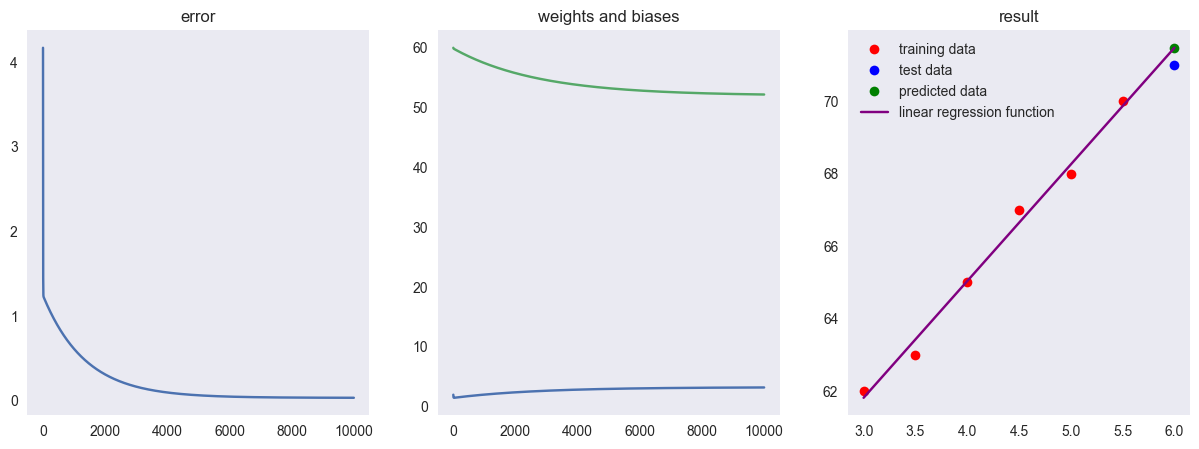

In [27]:
#|include: false

import matplotlib.pyplot as plt

x_data = spannung[classes == '1']
y_data = strom[classes == '1']
print('x_data: ', x_data)
print('y_data: ',y_data)

x_train = x_data[:-1]
x_test = x_data[-1:]
print('x_train: ',x_train)
print('x_test: ',x_test)

y_train = y_data[:-1]
y_test = y_data[-1:]
print('y_train: ',y_train)
print('y_test: ',y_test)

model = MyPerceptron()

w = 2
b = 60

errors, weights, biases, w_final, b_final = model.fit(
    10000, x_train, y_train, w, b, alpha=0.01
)

y_pred = model.predict(x_test, w_final, b_final)

x_range_data = np.linspace(x_data.min(), x_data.max(), 100)
y_pred_range = model.predict(x_range_data, w_final, b_final)

print(weights[-1], biases[-1])

fig, [ax1, ax2, ax3] = plt.subplots(1,3, figsize = (15,5))

ax1.plot(errors)
ax1.set_title('error')
ax1.grid()

ax2.plot(weights)
ax2.plot(biases)
ax2.set_title('weights and biases')
ax2.grid()

ax3.plot(x_train, y_train, 'o', c= 'red', label = 'training data')
ax3.plot(x_test, y_test, 'o', c= 'blue', label = 'test data')
ax3.plot(x_test, y_pred, 'o', c= 'green', label = 'predicted data')
ax3.plot(x_range_data, y_pred_range, '-', c = 'purple', label = 'linear regression function')
ax3.set_title('result')
ax3.legend()
ax3.grid()
